# 03 — Descriptive Analytics

**Project:** Explainable Scenario-Based Simulation of Aircraft Damage Consequences Among Reported Wildlife Strikes Using FAA Data

## Purpose

This notebook describes the historical patterns found in the canonical analytical dataset produced by Notebook 02:

`data/processed/faa_strikes_analytical.csv`

It answers the descriptive question:

> **What historical patterns characterize reported wildlife strikes and reported aircraft damage?**

The notebook compares reporting volume and damage proportion across temporal, geographic, wildlife, aircraft, and flight-context variables. Counts are shown beside rates so that small categories are not mistaken for stable high-risk groups.

Formal hypothesis tests, effect sizes, confidence-interval comparisons intended as inferential evidence, and multivariable logistic regression belong in **Notebook 04 — Diagnostic Analytics**. Notebook 03 identifies the patterns and anomalies that Notebook 04 should examine.

## Interpretation boundary

All results are conditional on a wildlife strike having been reported. Airport, state, and regional counts are not ordinary-flight strike probabilities because the dataset does not contain exposure measures such as aircraft movements. The analysis uses association language and does not make causal claims. Changes across years may partly reflect reporting practices, field availability, or operational changes.


In [1]:

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 150)

SEED = 42
np.random.seed(SEED)

# Locate the repository root without using machine-specific paths.
ROOT = Path.cwd()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "data").exists() or (candidate / "docs").exists():
        ROOT = candidate
        break

DATA_DIR = ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
DOCS_DIR = ROOT / "docs"
PREP_OUTPUT_DIR = ROOT / "outputs" / "02_data_preparation"

INPUT_FILE = PROCESSED_DIR / "faa_strikes_analytical.csv"
if not INPUT_FILE.exists():
    local_candidate = Path.cwd() / "faa_strikes_analytical.csv"
    if local_candidate.exists():
        INPUT_FILE = local_candidate
FEATURE_LIST_FILE = DOCS_DIR / "feature_lists.json"
FEATURE_ELIGIBILITY_FILE = DOCS_DIR / "feature_eligibility.csv"
VALIDATION_METADATA_FILE = PREP_OUTPUT_DIR / "validation_metadata.json"

OUTPUT_DIR = ROOT / "outputs" / "03_descriptive_analytics"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"

for folder in [OUTPUT_DIR, TABLE_DIR, FIGURE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Repository root:", ROOT)
print("Canonical input:", INPUT_FILE)
print("Output folder:", OUTPUT_DIR)


Repository root: c:\Users\davis\Programing\MDA_programs\Capstone\faa-wildlife-strike-damage-analysis
Canonical input: c:\Users\davis\Programing\MDA_programs\Capstone\faa-wildlife-strike-damage-analysis\data\processed\faa_strikes_analytical.csv
Output folder: c:\Users\davis\Programing\MDA_programs\Capstone\faa-wildlife-strike-damage-analysis\outputs\03_descriptive_analytics


## 1. Load and validate the Notebook 02 hand-off

Notebook 03 uses the canonical analytical dataset produced by Notebook 02 and does not create a second independently cleaned version. The complete analytical export is required because this notebook describes post-event consequences that were intentionally excluded from the restricted dataset prepared for binary damage modelling.

In [2]:

if not INPUT_FILE.exists():
    raise FileNotFoundError(
        f"Canonical Notebook 02 output not found: {INPUT_FILE.resolve()}\n"
        "Run Notebook 02 from a fresh kernel before running this notebook."
    )

df = pd.read_csv(INPUT_FILE, low_memory=False)

required_fields = {
    "INDEX_NR",
    "INCIDENT_YEAR",
    "INCIDENT_MONTH",
    "INDICATED_DAMAGE",
    "SEASON",
    "WILDLIFE_TYPE",
    "SIZE",
    "NUM_STRUCK",
    "AC_CLASS",
    "AC_MASS_GROUP",
    "TYPE_ENG",
    "NUM_ENGS",
    "WARNED",
    "TEMPORAL_SPLIT",
}

missing_required = sorted(required_fields - set(df.columns))
if missing_required:
    raise KeyError(
        "Notebook 02 analytical output is missing required fields: "
        + ", ".join(missing_required)
    )

# Load preparation metadata when available.
feature_lists = {}
if FEATURE_LIST_FILE.exists():
    with open(FEATURE_LIST_FILE, "r", encoding="utf-8") as f:
        feature_lists = json.load(f)

validation_metadata = {}
if VALIDATION_METADATA_FILE.exists():
    with open(VALIDATION_METADATA_FILE, "r", encoding="utf-8") as f:
        validation_metadata = json.load(f)

feature_eligibility = (
    pd.read_csv(FEATURE_ELIGIBILITY_FILE)
    if FEATURE_ELIGIBILITY_FILE.exists()
    else pd.DataFrame()
)

print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]:,} columns")
print("Observed years:", int(df["INCIDENT_YEAR"].min()), "to", int(df["INCIDENT_YEAR"].max()))
print("Feature-list metadata loaded:", bool(feature_lists))
print("Validation metadata loaded:", bool(validation_metadata))
display(df.head())


Loaded: 319,107 rows × 150 columns
Observed years: 1990 to 2024
Feature-list metadata loaded: True
Validation metadata loaded: True


,INDEX_NR,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,AIRPORT_LATITUDE,AIRPORT_LONGITUDE,RUNWAY,STATE,FAAREGION,LOCATION,ENROUTE_STATE,OPID,OPERATOR,REG,FLT,AIRCRAFT,AMA,AMO,EMA,EMO,AC_CLASS,AC_MASS,TYPE_ENG,NUM_ENGS,ENG_1_POS,ENG_2_POS,ENG_3_POS,ENG_4_POS,PHASE_OF_FLIGHT,HEIGHT,SPEED,DISTANCE,INCIDENT_LATITUDE,INCIDENT_LONGITUDE,SKY,PRECIPITATION,AOS,COST_REPAIRS,COST_OTHER,COST_REPAIRS_INFL_ADJ,COST_OTHER_INFL_ADJ,INGESTED_OTHER,INDICATED_DAMAGE,DAMAGE_LEVEL,STR_RAD,DAM_RAD,STR_WINDSHLD,DAM_WINDSHLD,STR_NOSE,DAM_NOSE,STR_ENG1,DAM_ENG1,ING_ENG1,STR_ENG2,DAM_ENG2,ING_ENG2,STR_ENG3,DAM_ENG3,ING_ENG3,STR_ENG4,DAM_ENG4,ING_ENG4,STR_PROP,DAM_PROP,STR_WING_ROT,DAM_WING_ROT,STR_FUSE,DAM_FUSE,STR_LG,DAM_LG,STR_TAIL,DAM_TAIL,STR_LGHTS,DAM_LGHTS,STR_OTHER,DAM_OTHER,OTHER_SPECIFY,EFFECT,EFFECT_OTHER,BIRD_BAND_NUMBER,SPECIES_ID,SPECIES,REMARKS,REMAINS_COLLECTED,REMAINS_SENT,WARNED,NUM_SEEN,NUM_STRUCK,SIZE,NR_INJURIES,NR_FATALITIES,COMMENTS,IMAGE,REPORTED_NAME,REPORTED_TITLE,SOURCE,PERSON,LUPDATE,TRANSFER,SPECIES_RAW,SPECIES_ID_RAW,SIZE_RAW,NUM_SEEN_RAW,NUM_STRUCK_RAW,PHASE_OF_FLIGHT_RAW,TIME_OF_DAY_RAW,WARNED_RAW,SKY_RAW,PRECIPITATION_RAW,AC_CLASS_RAW,DAMAGE_LEVEL_RAW,NUM_SEEN_ORDER,NUM_STRUCK_ORDER,TARGET_CONFLICT_FLAG,SEVERITY_ELIGIBLE_FLAG,WILDLIFE_TYPE_INITIAL,WILDLIFE_TYPE,WILDLIFE_TYPE_OVERRIDE,WILDLIFE_TYPE_OVERRIDE_FLAG,HEIGHT_INVALID_NEGATIVE_FLAG,HEIGHT_EXTREME_REVIEW_FLAG,SPEED_INVALID_NEGATIVE_FLAG,SPEED_EXTREME_REVIEW_FLAG,DISTANCE_INVALID_NEGATIVE_FLAG,DISTANCE_EXTREME_REVIEW_FLAG,NUM_ENGS_INVALID_NEGATIVE_FLAG,NUM_ENGS_EXTREME_REVIEW_FLAG,AC_MASS_INVALID_NEGATIVE_FLAG,AC_MASS_EXTREME_REVIEW_FLAG,NR_INJURIES_INVALID_NEGATIVE_FLAG,NR_INJURIES_EXTREME_REVIEW_FLAG,NR_FATALITIES_INVALID_NEGATIVE_FLAG,NR_FATALITIES_EXTREME_REVIEW_FLAG,GROUND_PHASE_HEIGHT_CONFLICT_FLAG,SEASON,MONTH_SIN,MONTH_COS,AC_MASS_GROUP,HEIGHT_MISSING_FLAG,SPEED_MISSING_FLAG,TIME_OF_DAY_MISSING_FLAG,PHASE_OF_FLIGHT_MISSING_FLAG,SIZE_MISSING_FLAG,SKY_MISSING_FLAG,PRECIPITATION_MISSING_FLAG,TEMPORAL_SPLIT
0,608242,6/22/1996 0:00:00,6,1996,NaN,Not reported,KSMF,SACRAMENTO INTL,NaN,NaN,NaN,CA,AWP,NaN,NaN,UAL,UNITED AIRLINES,NaN,1768,B-737-300,148,24,10.0,1.0,A,4.0,D,2.0,1.0,1.0,NaN,NaN,Take-off Run,0.0,NaN,0.0,NaN,NaN,Not reported,Not reported,NaN,NaN,NaN,NaN,NaN,0,0,NaN,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,UNKBM,Unknown bird - medium,BLOOD ON L FWD NOSE AREA SEEN BY CREW AFTER LDG.,0,0,Unknown,Not reported,1,Medium,0.0,0.0,/Legacy Record 100001/,0,REDACTED,REDACTED,Air Transport Report,Air Transport Operations,12/20/2007 0:00:00,0,Unknown bird - medium,UNKBM,Medium,NaN,1,Take-off Run,NaN,Unknown,NaN,NaN,A,NaN,NaN,1.0,0,0,Bird,Bird,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Summer,1.224647e-16,-1.000000,Heavy,0,1,1,0,0,1,1,train_1990_2018
1,608243,6/26/1996 0:00:00,6,1996,NaN,Not reported,KDEN,DENVER INTL AIRPORT,NaN,NaN,NaN,CO,ANM,NaN,NaN,UAL,UNITED AIRLINES,NaN,1845,B-737-300,148,24,10.0,1.0,A,4.0,D,2.0,1.0,1.0,NaN,NaN,Take-off Run,0.0,NaN,0.0,NaN,NaN,Not reported,Not reported,NaN,NaN,NaN,NaN,NaN,0,0,NaN,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,UNKBM,Unknown bird - medium,CREW SUSPECTED BIRDSTRIKE ON T/O. LOOKED LIKE ...,0,0,Unknown,Not reported,1,Medium,0.0,0.0,/Legacy Record 100002/,0,REDACTED,REDACTED,Air Transport Report,Air Transport Operations,12/20/2007 0:00:00,0,Unknown bird - medium,UNKBM,Medium,NaN,1,Take-off Run,NaN,Unknown,NaN,NaN,A,NaN,NaN,1.0,0,0,Bird,Bird,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Summer,1.224647e-16,-1.000000,Heavy,0,1,1,0,0,1,1,train_1990_2018
2,608244,7/1/1996 0:00:00,7,1996,NaN,Not reported,KOMA,EPPLEY AIRFIELD,NaN,NaN,NaN,NE,ACE,NaN,NaN,UAL,UNITED AIRLINES,NaN,306,B-757-200,148,26,34.0,40.0,A,4.0,D,2.0,1.0,1.0,NaN,NaN,Take-off Run,0.0,NaN,0.0,NaN,NaN,Not reported,Not reported,NaN,NaN,NaN,NaN,NaN,0,0,N,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,UNKBM,Unknown bird - medium,BIRDSTRIKE AT 

In [3]:

# Validate the locked population and primary target.
df["INCIDENT_YEAR"] = pd.to_numeric(df["INCIDENT_YEAR"], errors="coerce").astype("Int64")
df["INCIDENT_MONTH"] = pd.to_numeric(df["INCIDENT_MONTH"], errors="coerce").astype("Int64")
df["INDICATED_DAMAGE"] = pd.to_numeric(
    df["INDICATED_DAMAGE"], errors="coerce"
).astype("Int64")

validation_checks = pd.DataFrame([
    {
        "check": "Rows",
        "result": len(df),
        "status": "information",
    },
    {
        "check": "Columns",
        "result": df.shape[1],
        "status": "information",
    },
    {
        "check": "Minimum year",
        "result": df["INCIDENT_YEAR"].min(),
        "status": "pass" if df["INCIDENT_YEAR"].min() == 1990 else "review",
    },
    {
        "check": "Maximum year",
        "result": df["INCIDENT_YEAR"].max(),
        "status": "pass" if df["INCIDENT_YEAR"].max() == 2024 else "review",
    },
    {
        "check": "Rows outside 1990–2024",
        "result": int((~df["INCIDENT_YEAR"].between(1990, 2024)).sum()),
        "status": "pass" if (~df["INCIDENT_YEAR"].between(1990, 2024)).sum() == 0 else "fail",
    },
    {
        "check": "Missing primary target",
        "result": int(df["INDICATED_DAMAGE"].isna().sum()),
        "status": "pass" if df["INDICATED_DAMAGE"].isna().sum() == 0 else "fail",
    },
    {
        "check": "Unexpected primary-target values",
        "result": sorted(
            set(df["INDICATED_DAMAGE"].dropna().astype(int).unique()) - {0, 1}
        ),
        "status": "pass"
        if set(df["INDICATED_DAMAGE"].dropna().astype(int).unique()).issubset({0, 1})
        else "fail",
    },
    {
        "check": "Exact duplicate rows",
        "result": int(df.duplicated().sum()),
        "status": "pass" if df.duplicated().sum() == 0 else "review",
    },
    {
        "check": "Repeated INDEX_NR values",
        "result": int(df["INDEX_NR"].duplicated(keep=False).sum()),
        "status": "pass" if df["INDEX_NR"].duplicated(keep=False).sum() == 0 else "review",
    },
])

display(validation_checks)
validation_checks.to_csv(TABLE_DIR / "00_dataset_validation.csv", index=False)

failed_checks = validation_checks.loc[
    validation_checks["status"].eq("fail"), "check"
].tolist()
if failed_checks:
    raise AssertionError(
        "Canonical-data validation failed: " + ", ".join(failed_checks)
    )


,check,result,status
0,Rows,319107,information
1,Columns,150,information
2,Minimum year,1990,pass
3,Maximum year,2024,pass
4,Rows outside 1990–2024,0,pass
5,Missing primary target,0,pass
6,Unexpected primary-target values,[],pass
7,Exact duplicate rows,0,pass
8,Repeated INDEX_NR values,0,pass


### Data hand-off and validation results

The notebook successfully loaded the canonical analytical dataset produced by Notebook 02. The dataset contains 319,107 reported wildlife-strike records and 150 variables covering the analytical period from 1990 to 2024. The feature-list and validation metadata were also loaded successfully, confirming consistency with the feature definitions, leakage controls, and validation design established during data preparation.

All validation checks passed. There were no records outside the selected analytical period, no exact duplicate rows, and no repeated `INDEX_NR` values. The primary target, `INDICATED_DAMAGE`, was complete for all 319,107 records and contained only the valid binary values 0 and 1. Although pandas displayed an `<NA>` category because the variable uses the nullable `Int64` data type, the number of records in this category was zero. The dataset is therefore suitable for descriptive, statistical, and subsequent predictive analyses.

## 2. Local descriptive-only derivations

The canonical Notebook 02 dataset is not modified or overwritten. `DAY_OF_WEEK` is derived locally from `INCIDENT_DATE` only for the descriptive analyses in this notebook. Notebook 02 remains the single source of truth for all cleaned and engineered variables used in subsequent modelling.

In [4]:

analysis_df = df.copy()

if "INCIDENT_DATE" in analysis_df.columns:
    try:
        incident_date = pd.to_datetime(
            analysis_df["INCIDENT_DATE"], errors="coerce", format="mixed"
        )
    except (TypeError, ValueError):
        incident_date = pd.to_datetime(
            analysis_df["INCIDENT_DATE"], errors="coerce"
        )
    analysis_df["DAY_OF_WEEK"] = incident_date.dt.day_name()
else:
    analysis_df["DAY_OF_WEEK"] = pd.NA

# Use the canonical state field from Notebook 02.
if "STATE" not in analysis_df.columns and "INCIDENT_STATE" in analysis_df.columns:
    warnings.warn(
        "Legacy INCIDENT_STATE found. A local STATE alias was created, but "
        "Notebook 02 should normally export STATE."
    )
    analysis_df["STATE"] = analysis_df["INCIDENT_STATE"]

# Do not change the canonical source file.
print("Local analysis copy created:", analysis_df.shape)


Local analysis copy created: (319107, 151)


### Local analytical derivation

A local analysis copy was created with the same 319,107 records as the canonical dataset. The number of variables increased from 150 to 151 because `DAY_OF_WEEK` was derived from `INCIDENT_DATE` for temporal descriptive analysis. This additional variable exists only in the local analytical copy and does not modify or overwrite the canonical dataset produced by Notebook 02.


## 3. Reusable output and summary functions

Reusable helper functions are defined to produce consistent tables, figures, and summary outputs throughout the notebook. All final tables are exported as CSV files, all final figures are saved as PNG files at 300 dpi, and a complete output manifest is generated at the end of the notebook.

In [5]:

output_manifest = []

def save_table(table, filename, folder=TABLE_DIR):
    path = folder / filename
    table.to_csv(path, index=False)
    output_manifest.append({
        "artifact_type": "table",
        "filename": filename,
        "relative_path": str(path.relative_to(ROOT)),
        "rows": len(table),
        "columns": table.shape[1],
    })
    return path

def save_figure(fig, filename):
    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=300, bbox_inches="tight")
    output_manifest.append({
        "artifact_type": "figure",
        "filename": filename,
        "relative_path": str(path.relative_to(ROOT)),
        "rows": pd.NA,
        "columns": pd.NA,
    })
    return path

def wilson_interval(successes, totals, z=1.96):
    successes = np.asarray(successes, dtype=float)
    totals = np.asarray(totals, dtype=float)

    with np.errstate(divide="ignore", invalid="ignore"):
        p = successes / totals
        denominator = 1 + (z ** 2 / totals)

        centre = (
            p + z ** 2 / (2 * totals)
        ) / denominator

        margin = (
            z
            * np.sqrt(
                (p * (1 - p) / totals)
                + (z ** 2 / (4 * totals ** 2))
            )
            / denominator
        )

    lower = np.clip(
        (centre - margin) * 100,
        0,
        100
    )

    upper = np.clip(
        (centre + margin) * 100,
        0,
        100
    )

    return lower, upper

def outcome_by_category(data, group_columns, sort_by="Reported_Strikes"):
    if isinstance(group_columns, str):
        group_columns = [group_columns]

    summary = (
        data.groupby(group_columns, dropna=False, observed=False)
        .agg(
            Reported_Strikes=("INDEX_NR", "size"),
            Damage_Records=("INDICATED_DAMAGE", "sum"),
        )
        .reset_index()
    )
    summary["No_Damage_Records"] = (
        summary["Reported_Strikes"] - summary["Damage_Records"]
    )
    summary["Damage_Rate_Pct"] = (
        summary["Damage_Records"] / summary["Reported_Strikes"] * 100
    )
    lower, upper = wilson_interval(
        summary["Damage_Records"], summary["Reported_Strikes"]
    )
    summary["Damage_Rate_CI95_Lower"] = lower
    summary["Damage_Rate_CI95_Upper"] = upper
    return summary.sort_values(sort_by, ascending=False).reset_index(drop=True)

def display_label_table(summary, category_columns):
    labelled = summary.copy()
    if isinstance(category_columns, str):
        category_columns = [category_columns]
    labelled["Category_Label"] = (
        labelled[category_columns]
        .astype("string")
        .fillna("Missing")
        .agg(" | ".join, axis=1)
    )
    return labelled

def plot_counts(summary, category_columns, title, filename, top_n=None):
    plot_data = display_label_table(summary, category_columns)
    if top_n is not None:
        plot_data = plot_data.nlargest(top_n, "Reported_Strikes")
    plot_data = plot_data.sort_values("Reported_Strikes", ascending=True)

    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(plot_data))))
    ax.barh(plot_data["Category_Label"], plot_data["Reported_Strikes"])
    ax.set_title(title)
    ax.set_xlabel("Number of reported strikes")
    ax.set_ylabel("")
    plt.tight_layout()
    save_figure(fig, filename)
    plt.show()

def plot_damage_rates(
    summary,
    category_columns,
    title,
    filename,
    top_n=None,
    minimum_records=1,
):
    plot_data = summary.loc[
        summary["Reported_Strikes"] >= minimum_records
    ].copy()
    if top_n is not None:
        plot_data = plot_data.nlargest(top_n, "Reported_Strikes")
    plot_data = display_label_table(plot_data, category_columns)
    plot_data = plot_data.sort_values("Damage_Rate_Pct", ascending=True)

    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(plot_data))))
    ax.barh(plot_data["Category_Label"], plot_data["Damage_Rate_Pct"])
    ax.set_title(title)
    ax.set_xlabel("Reported aircraft-damage rate (%)")
    ax.set_ylabel("")
    plt.tight_layout()
    save_figure(fig, filename)
    plt.show()


In [6]:
print(analysis_df["INDICATED_DAMAGE"].dtype)
print(analysis_df["INDICATED_DAMAGE"].value_counts(dropna=False))
print(analysis_df["INDICATED_DAMAGE"].unique())

Int64
INDICATED_DAMAGE
0    298199
1     20908
Name: count, dtype: Int64
<IntegerArray>
[0, 1]
Length: 2, dtype: Int64


## 4. Dataset overview and target distribution

This section summarizes the analytical dataset and examines the distribution of the primary binary target, `INDICATED_DAMAGE`. It confirms the number of records, analytical period, target completeness, and the level of class imbalance before the descriptive analyses.

,Metric,Value
0,Reported strike records,319107.000000
1,First analytical year,1990.000000
2,Last analytical year,2024.000000
3,Reporting years,35.000000
4,Damaging records,20908.000000
5,Non-damaging records,298199.000000
6,Overall reported damage rate (%),6.552034
7,Distinct FAA regions,11.000000
8,Distinct states,68.000000
9,Distinct airports,2708.000000


,INDICATED_DAMAGE,Records,Damage_Status,Percentage
0,0,298199,No damage reported,93.447966
1,1,20908,Damage reported,6.552034


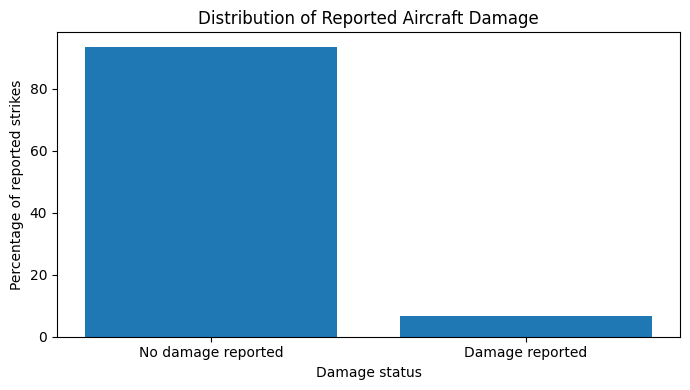

In [7]:
overall_summary = pd.DataFrame({
    "Metric": [
        "Reported strike records",
        "First analytical year",
        "Last analytical year",
        "Reporting years",
        "Damaging records",
        "Non-damaging records",
        "Overall reported damage rate (%)",
        "Distinct FAA regions",
        "Distinct states",
        "Distinct airports",
        "Distinct exact species labels",
        "Distinct broad wildlife types",
        "Target conflict flags",
    ],
    "Value": [
        len(analysis_df),
        analysis_df["INCIDENT_YEAR"].min(),
        analysis_df["INCIDENT_YEAR"].max(),
        analysis_df["INCIDENT_YEAR"].nunique(),
        int(analysis_df["INDICATED_DAMAGE"].sum()),
        int((analysis_df["INDICATED_DAMAGE"] == 0).sum()),
        analysis_df["INDICATED_DAMAGE"].mean() * 100,
        (
            analysis_df["FAAREGION"].nunique(dropna=False)
            if "FAAREGION" in analysis_df.columns
            else pd.NA
        ),
        (
            analysis_df["STATE"].nunique(dropna=False)
            if "STATE" in analysis_df.columns
            else pd.NA
        ),
        (
            analysis_df["AIRPORT_ID"].nunique(dropna=False)
            if "AIRPORT_ID" in analysis_df.columns
            else pd.NA
        ),
        (
            analysis_df["SPECIES"].nunique(dropna=False)
            if "SPECIES" in analysis_df.columns
            else pd.NA
        ),
        (
            analysis_df["WILDLIFE_TYPE"].nunique(dropna=False)
            if "WILDLIFE_TYPE" in analysis_df.columns
            else pd.NA
        ),
        (
            int(
                pd.to_numeric(
                    analysis_df["TARGET_CONFLICT_FLAG"],
                    errors="coerce"
                )
                .fillna(0)
                .sum()
            )
            if "TARGET_CONFLICT_FLAG" in analysis_df.columns
            else pd.NA
        ),
    ],
})

# Create damage distribution.
# dropna=True prevents the empty <NA> category from appearing.
damage_distribution = (
    analysis_df["INDICATED_DAMAGE"]
    .value_counts(dropna=True)
    .sort_index()
    .rename_axis("INDICATED_DAMAGE")
    .reset_index(name="Records")
)

damage_distribution["Damage_Status"] = (
    damage_distribution["INDICATED_DAMAGE"]
    .astype(int)
    .map({
        0: "No damage reported",
        1: "Damage reported",
    })
)

damage_distribution["Percentage"] = (
    damage_distribution["Records"].astype(float)
    / len(analysis_df)
    * 100
)

# Export tables.
save_table(
    overall_summary,
    "01_overall_summary.csv"
)

save_table(
    damage_distribution,
    "02_damage_distribution.csv"
)

# Display tables.
display(overall_summary)
display(damage_distribution)

# Create and export figure.
fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(
    damage_distribution["Damage_Status"].astype(str),
    damage_distribution["Percentage"].astype(float)
)

ax.set_title("Distribution of Reported Aircraft Damage")
ax.set_xlabel("Damage status")
ax.set_ylabel("Percentage of reported strikes")

plt.tight_layout()

save_figure(
    fig,
    "01_damage_distribution.png"
)

plt.show()

### Dataset overview and damage distribution

The dataset contains 319,107 reported wildlife-strike records from 1990 to 2024. Aircraft damage was reported in 20,908 records (6.55%), while 298,199 records (93.45%) reported no damage.

This class imbalance should be considered during model training and evaluation. No target conflicts were identified. The damage rate applies only to reported wildlife strikes and does not represent the probability of damage during an ordinary flight.


## 5. RQ1 descriptive association tables

Each table reports record counts, reported damage counts, damage rates, and 95% Wilson confidence intervals. Counts and rates are presented together because categories with many reported strikes do not necessarily have high damage rates, while high rates based on small record counts may be less precise.

In [8]:

# Canonical category orders from Notebook 02.
category_orders = {
    "INCIDENT_MONTH": list(range(1, 13)),
    "SEASON": ["Winter", "Spring", "Summer", "Autumn", "Unknown"],
    "DAY_OF_WEEK": [
        "Monday", "Tuesday", "Wednesday", "Thursday",
        "Friday", "Saturday", "Sunday"
    ],
    "TIME_OF_DAY": ["Dawn", "Day", "Dusk", "Night", "Unknown", "Not reported"],
    "SIZE": ["Small", "Medium", "Large", "Unknown", "Not reported"],
    "NUM_STRUCK": [
        "1", "2–10", "11–100", "More than 100", "Unknown", "Not reported"
    ],
    "AC_MASS_GROUP": ["Light", "Medium", "Heavy", "Unknown"],
    "WARNED": ["Yes", "No", "Unknown", "Not reported"],
}

analysis_specs = {
    "temporal": [
        ("INCIDENT_YEAR", "incident_year"),
        ("INCIDENT_MONTH", "incident_month"),
        ("SEASON", "season"),
        ("DAY_OF_WEEK", "day_of_week"),
        ("TIME_OF_DAY", "time_of_day"),
    ],
    "geographic": [
        ("FAAREGION", "faa_region"),
        ("STATE", "state"),
    ],
    "wildlife": [
        ("WILDLIFE_TYPE", "wildlife_type"),
        ("SIZE", "wildlife_size"),
        ("NUM_STRUCK", "number_struck"),
        ("SPECIES", "exact_species"),
    ],
    "aircraft": [
        ("AC_CLASS", "aircraft_class"),
        ("AC_MASS_GROUP", "aircraft_mass_group"),
        ("TYPE_ENG", "engine_type"),
        ("NUM_ENGS", "number_of_engines"),
    ],
    "flight": [
        ("PHASE_OF_FLIGHT", "phase_of_flight"),
        ("WARNED", "warning_status"),
    ],
    "environmental_context": [
        ("SKY", "sky_condition"),
        ("PRECIPITATION", "precipitation"),
    ],
}

summary_tables = {}

for domain, specifications in analysis_specs.items():
    for column, stem in specifications:
        if column not in analysis_df.columns:
            warnings.warn(f"Skipping unavailable field: {column}")
            continue

        summary = outcome_by_category(analysis_df, column)

        if column in category_orders:
            order_map = {
                value: position
                for position, value in enumerate(category_orders[column])
            }
            summary["_order"] = summary[column].map(order_map).fillna(999)
            summary = (
                summary.sort_values(
                    ["_order", "Reported_Strikes"],
                    ascending=[True, False]
                )
                .drop(columns="_order")
                .reset_index(drop=True)
            )

        key = f"{domain}_{stem}"
        summary_tables[key] = summary
        save_table(summary, f"{domain}_{stem}.csv")

# Airport needs both identifier and name.
if {"AIRPORT_ID", "AIRPORT"}.issubset(analysis_df.columns):
    airport_summary = outcome_by_category(
        analysis_df, ["AIRPORT_ID", "AIRPORT"]
    )
    summary_tables["geographic_airport"] = airport_summary
    save_table(airport_summary, "geographic_airport.csv")

print(f"Exported {len(summary_tables)} RQ1 descriptive tables.")


Exported 20 RQ1 descriptive tables.


In [9]:

# Display the core proposal-aligned summaries.
core_display_keys = [
    "temporal_season",
    "geographic_faa_region",
    "wildlife_wildlife_type",
    "wildlife_wildlife_size",
    "wildlife_number_struck",
    "aircraft_aircraft_class",
    "aircraft_aircraft_mass_group",
    "aircraft_engine_type",
    "flight_phase_of_flight",
    "flight_warning_status",
]

for key in core_display_keys:
    if key in summary_tables:
        print("\n", key)
        display(summary_tables[key])



 temporal_season


,SEASON,Reported_Strikes,Damage_Records,No_Damage_Records,Damage_Rate_Pct,Damage_Rate_CI95_Lower,Damage_Rate_CI95_Upper
0,Winter,32443,3559,28884,10.970009,10.634550,11.314710
1,Spring,68557,5247,63310,7.653485,7.456842,7.854875
2,Summer,112062,4667,107395,4.164659,4.049250,4.283210
3,Autumn,106045,7435,98610,7.011175,6.859045,7.166418



 geographic_faa_region


,FAAREGION,Reported_Strikes,Damage_Records,No_Damage_Records,Damage_Rate_Pct,Damage_Rate_CI95_Lower,Damage_Rate_CI95_Upper
0,ASO,60200,3539,56661,5.878738,5.693630,6.069475
1,AEA,43555,2923,40632,6.711055,6.479863,6.949882
2,AGL,43425,2441,40984,5.621186,5.408446,5.841777
3,Not reported,41103,4295,36808,10.449359,10.157314,10.748796
4,ASW,37244,1803,35441,4.841048,4.627684,5.063727
5,AWP,34022,2203,31819,6.475222,6.218607,6.741664
6,ANM,29340,1581,27759,5.388548,5.135974,5.652803
7,ACE,12986,818,12168,6.299091,5.894019,6.730012
8,ANE,10312,632,9680,6.128782,5.681963,6.608276
9,FGN,5340,464,4876,8.689139,7.963023,9.474649



 wildlife_wildlife_type


...

,TYPE_ENG,Reported_Strikes,Damage_Records,No_Damage_Records,Damage_Rate_Pct,Damage_Rate_CI95_Lower,Damage_Rate_CI95_Upper
0,D,192284,13250,179034,6.890849,6.778490,7.004931
1,Not reported,91258,312,90946,0.341888,0.306049,0.381907
2,C,15364,2246,13118,14.618589,14.068785,15.186082
3,A,15167,4153,11014,27.381816,26.677934,28.097152
4,F,4613,842,3771,18.252764,17.164613,19.393748
5,B,413,102,311,24.697337,20.783959,29.077091
6,E,5,3,2,60.0,23.071993,88.238177
7,Y,3,0,3,0.0,0.000000,56.150608



 flight_phase_of_flight


,PHASE_OF_FLIGHT,Reported_Strikes,Damage_Records,No_Damage_Records,Damage_Rate_Pct,Damage_Rate_CI95_Lower,Damage_Rate_CI95_Upper
0,Not reported,124521,2500,122021,2.007693,1.931254,2.087094
1,Approach,82366,7172,75194,8.707476,8.516846,8.901958
2,Landing Roll,35183,2005,33178,5.698775,5.461340,5.945883
3,Take-off Run,32638,2473,30165,7.577057,7.294923,7.869178
4,Climb,29077,4287,24790,14.743612,14.340752,15.155787
5,En Route,5871,1774,4097,30.216317,29.054946,31.403562
6,Departure,3546,116,3430,3.271292,2.734501,3.909221
7,Descent,2707,402,2305,14.850388,13.560631,16.239767
8,Local,1404,91,1313,6.481481,5.308689,7.891773
9,Arrival,927,43,884,4.638619,3.461784,6.189869



 flight_warning_status


,WARNED,Reported_Strikes,Damage_Records,No_Damage_Records,Damage_Rate_Pct,Damage_Rate_CI95_Lower,Damage_Rate_CI95_Upper
0,Yes,56494,4152,52342,7.349453,7.137159,7.567548
1,No,64521,7579,56942,11.746563,11.500395,11.997287
2,Unknown,198092,9177,188915,4.632696,4.541009,4.726142


### Key descriptive findings for RQ1

Damage patterns differed across temporal, geographic, wildlife, aircraft, and flight characteristics. Winter had the highest seasonal damage rate at 10.97%, while summer had the largest number of reported strikes but the lowest seasonal damage rate at 4.16%. Geographic damage rates also varied, although the high rate for records with an unreported FAA region indicates that missing geographic information must be considered.

Wildlife characteristics showed clear descriptive patterns. Large wildlife had a damage rate of 32.96%, compared with 12.59% for medium and 2.04% for small wildlife. Damage rates also increased with the reported number struck, from 5.87% for one animal to 20.38% for 11–100 animals. The estimate for more than 100 animals was high but based on only 57 records and therefore had a wide confidence interval.

Birds dominate the standardized broad wildlife classification, accounting for 293,433 of the 319,107 reported strikes. Their reported aircraft-damage rate was 6.31%. Terrestrial mammals were much less frequent, with 5,812 reports, but had the highest damage proportion among the broad groups at 22.99%. `Other wildlife` recorded a 7.65% damage rate, while bats and reptiles had substantially lower rates.

The contrast between frequency and damage proportion is important: birds make up most reported strikes, whereas terrestrial mammals show a much higher proportion of reported aircraft damage. These are descriptive associations among reported incidents and do not establish that wildlife type independently causes the observed differences.

Flight phase showed substantial variation. En-route strikes had the highest reported damage rate at 30.22%, followed by descent and climb at approximately 15%. Records in which no warning was reported had a higher damage rate than records with a warning. These results describe associations among reported strikes only; statistical tests and effect sizes are required before determining which factors have the strongest practical relationships with aircraft damage.


## 6. Final descriptive figures

This section presents the main descriptive figures used to visualize reported strike counts and damage rates. For high-cardinality variables such as airports and species, minimum record thresholds are applied only to improve the stability and readability of the figures. The complete unfiltered results remain available in the exported tables.

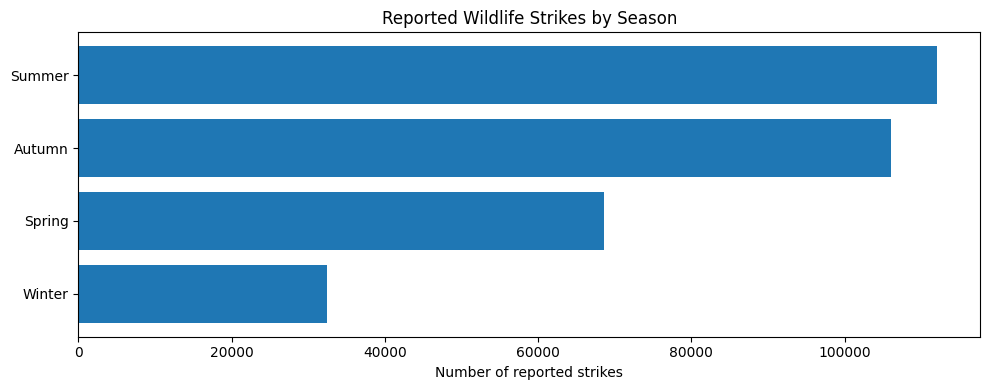

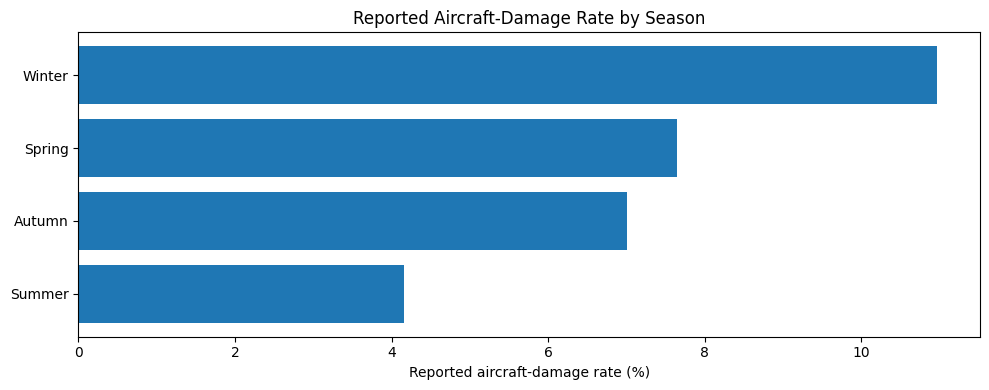

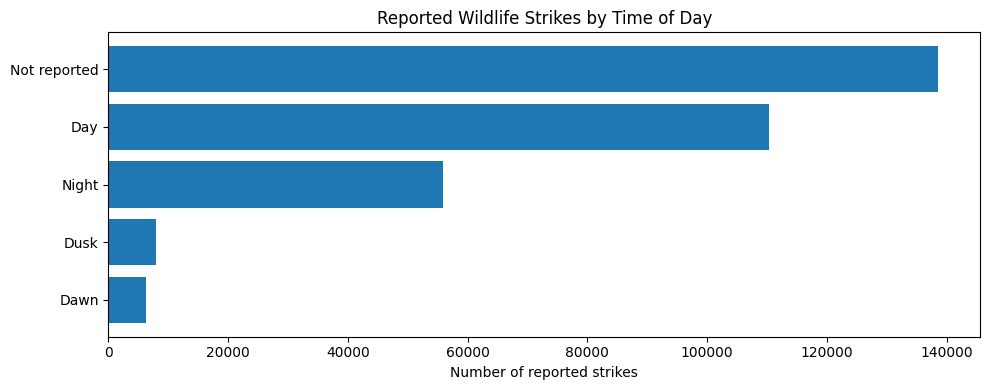

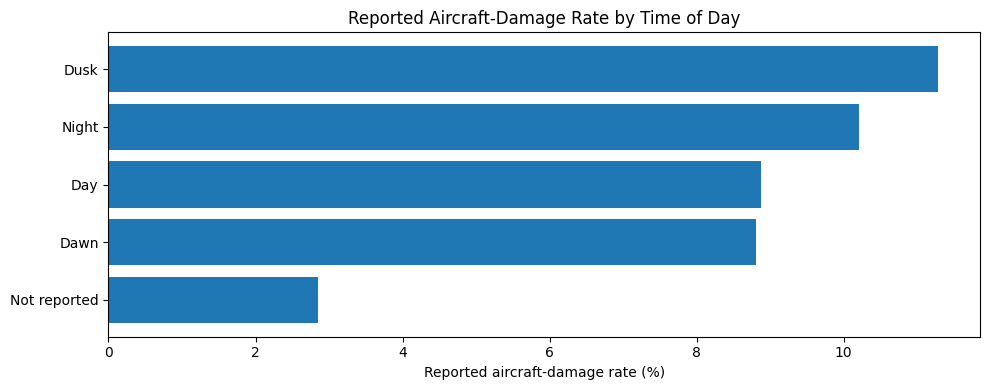

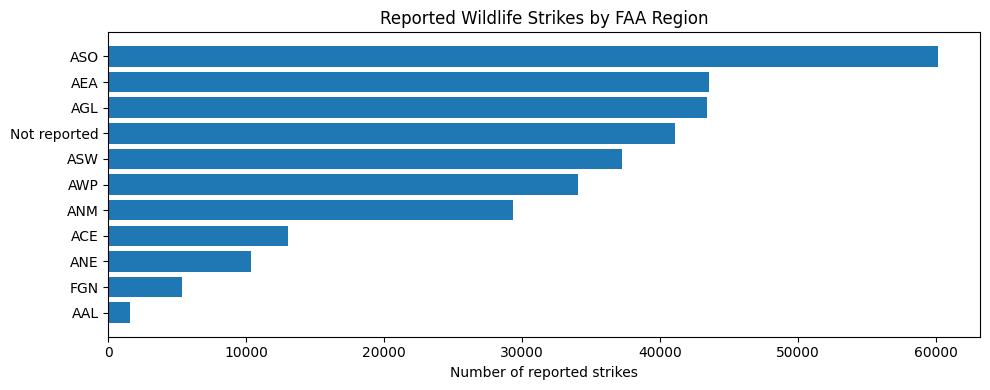

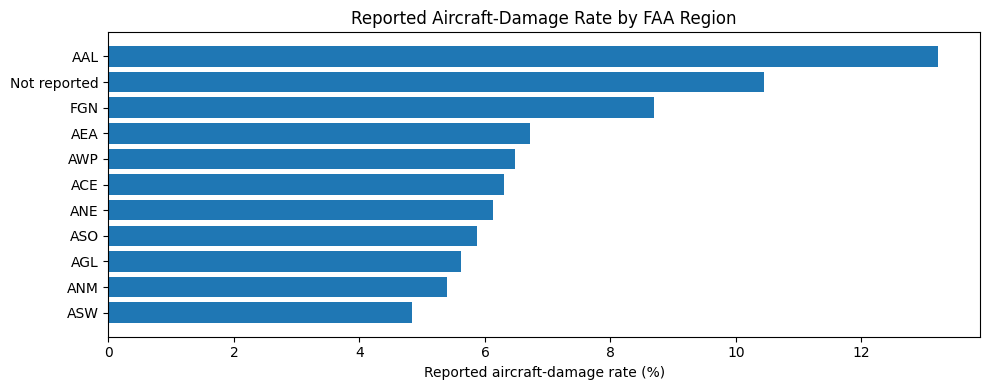

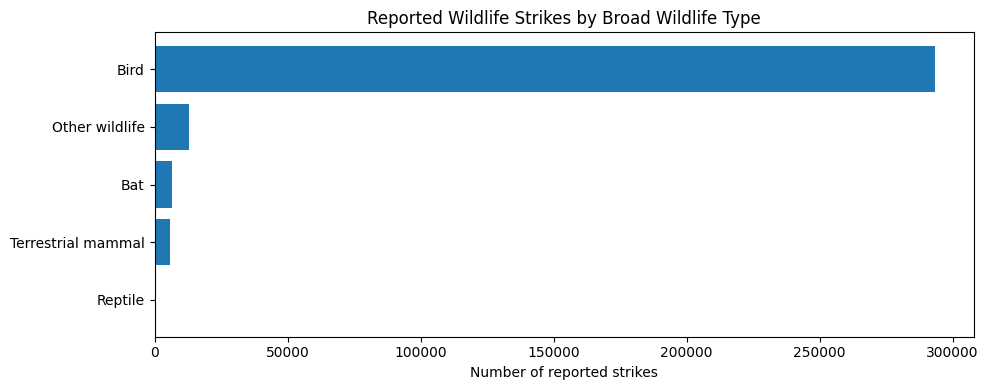

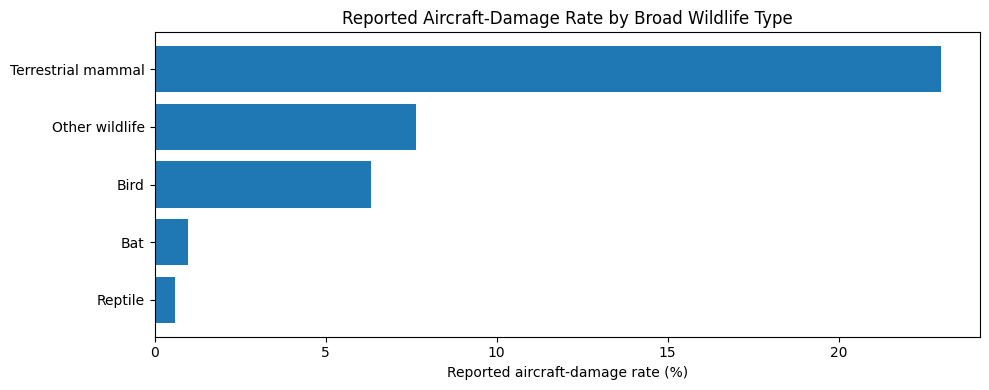

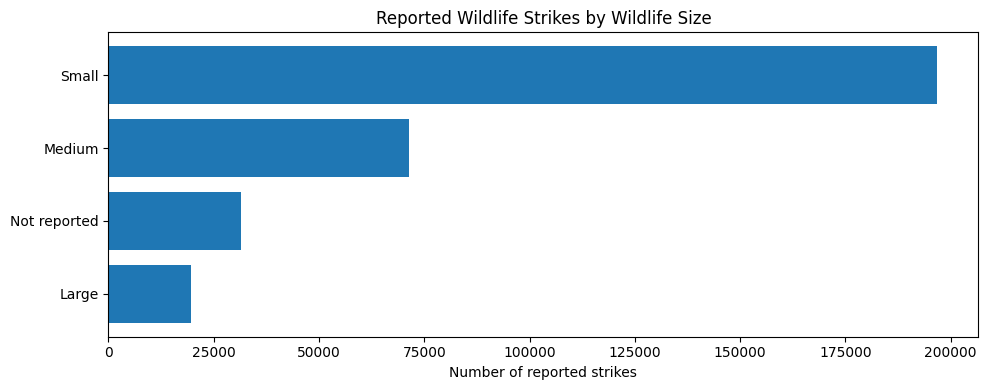

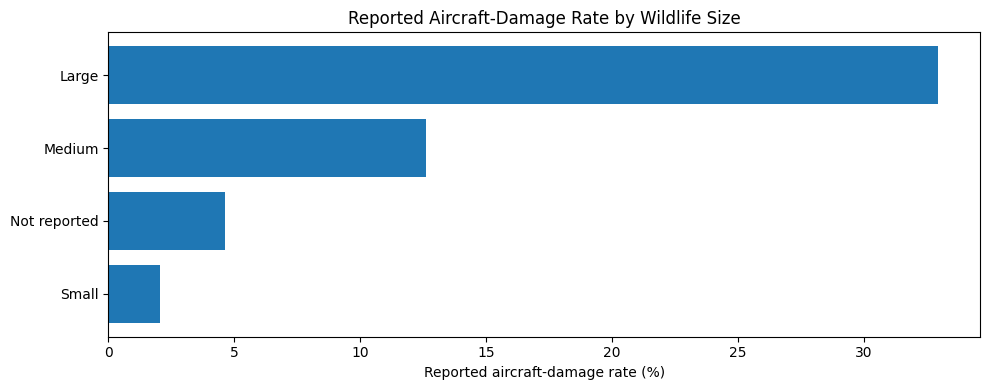

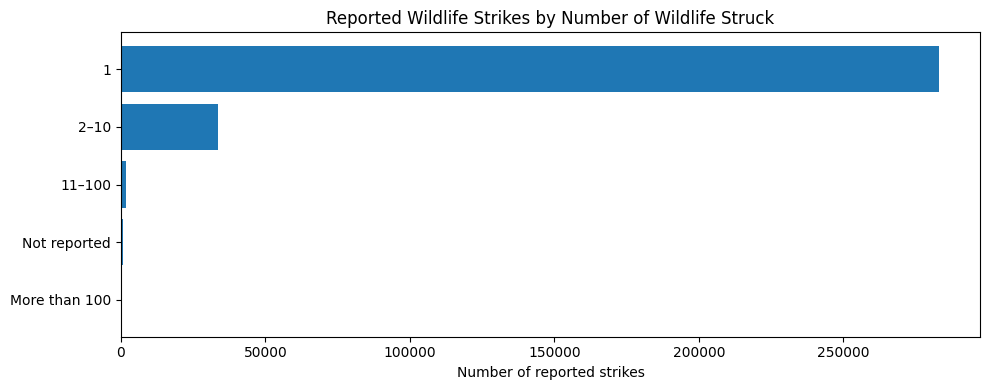

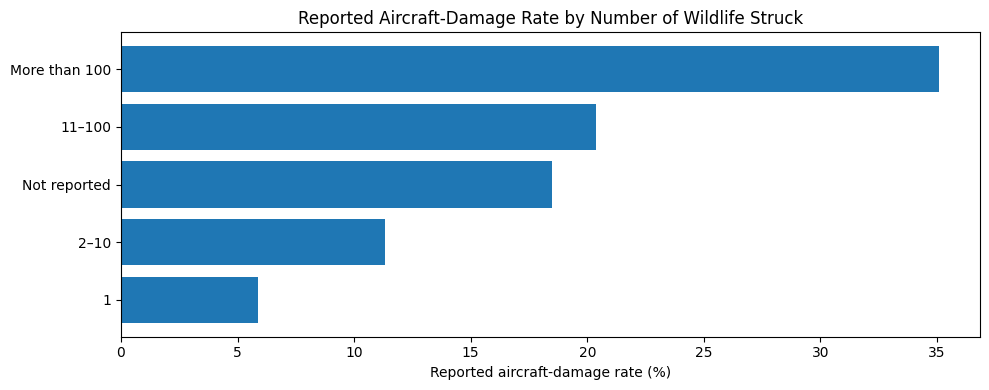

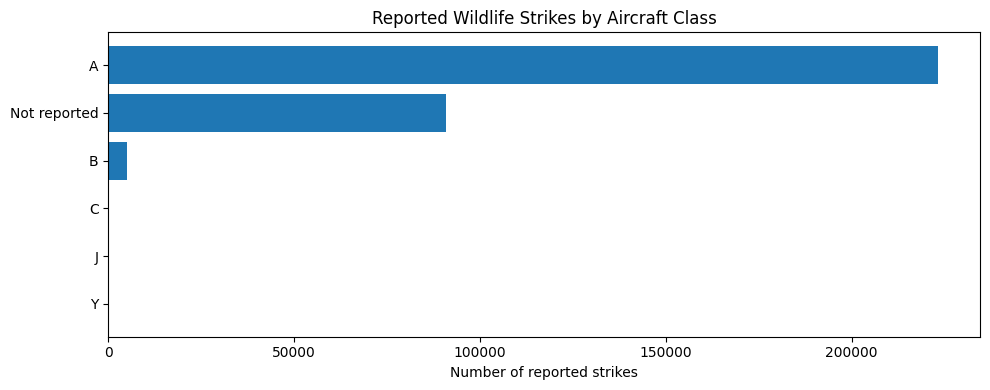

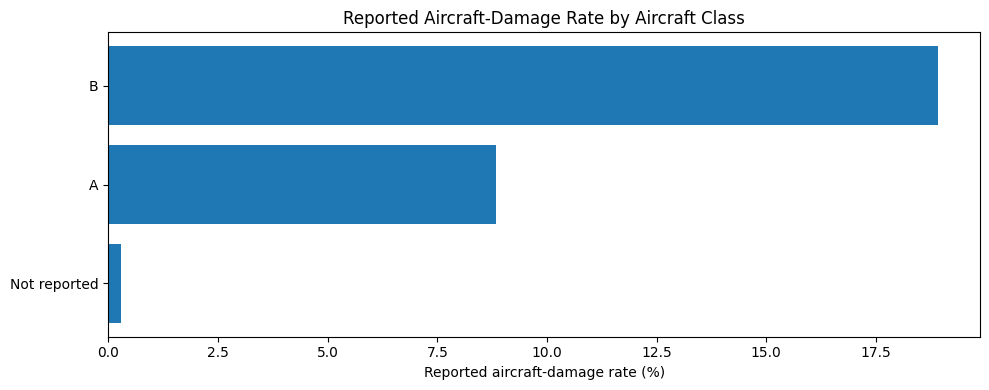

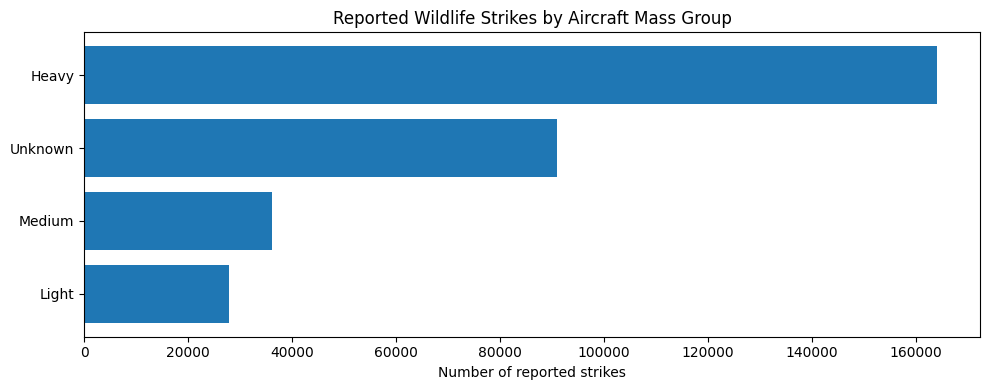

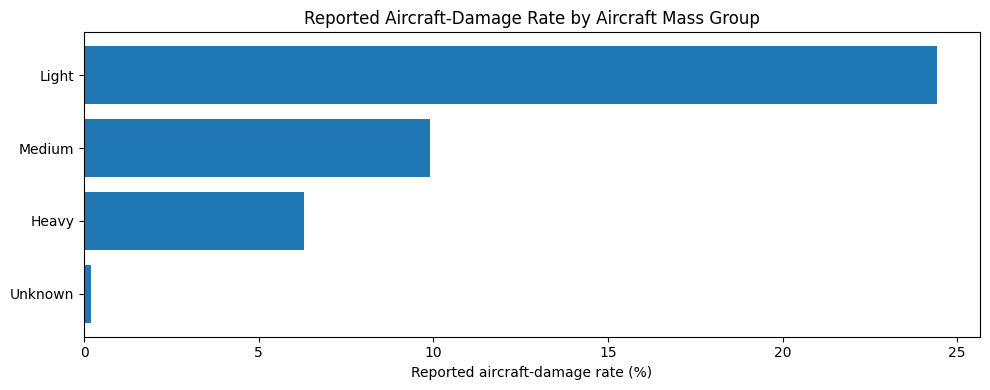

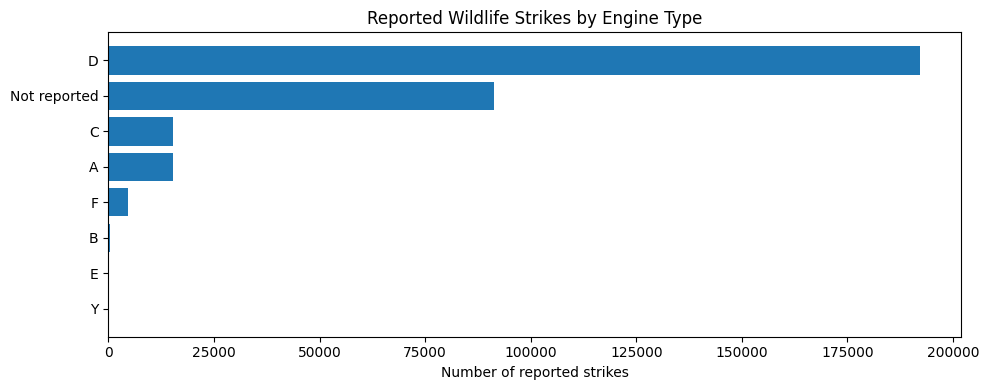

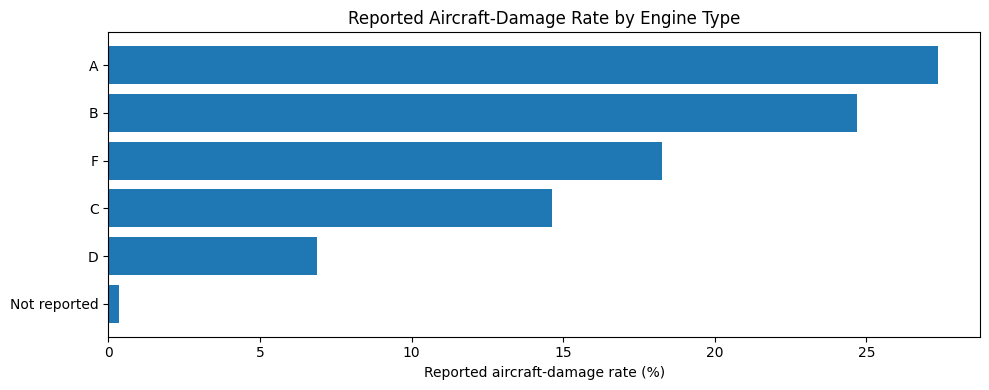

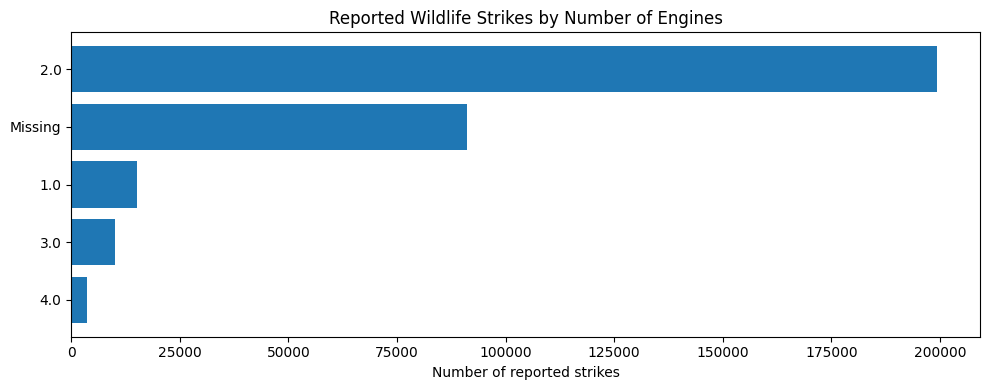

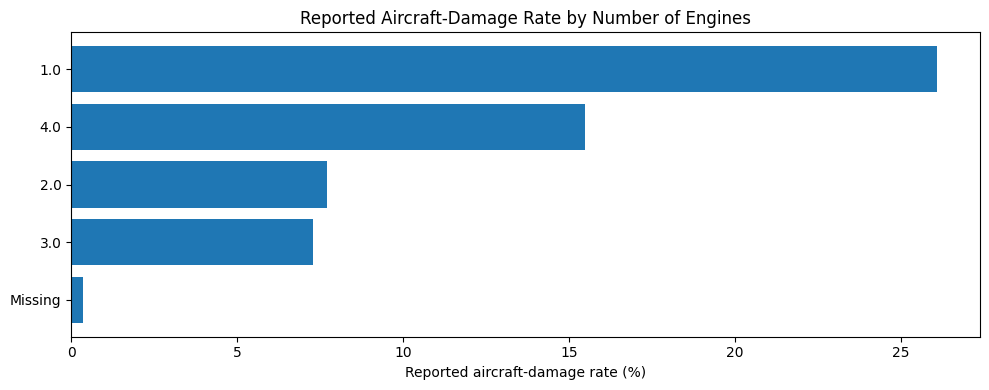

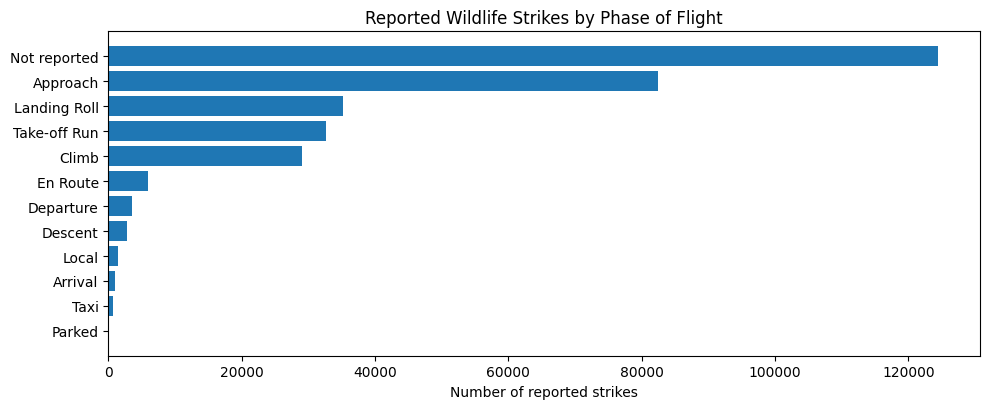

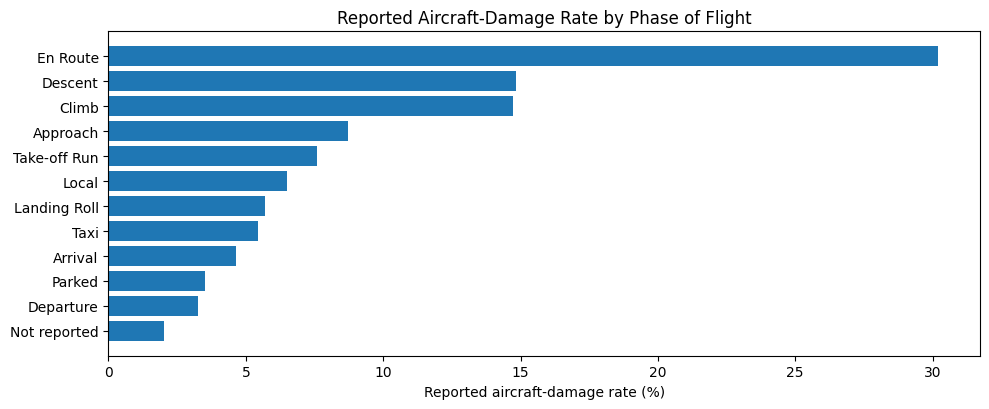

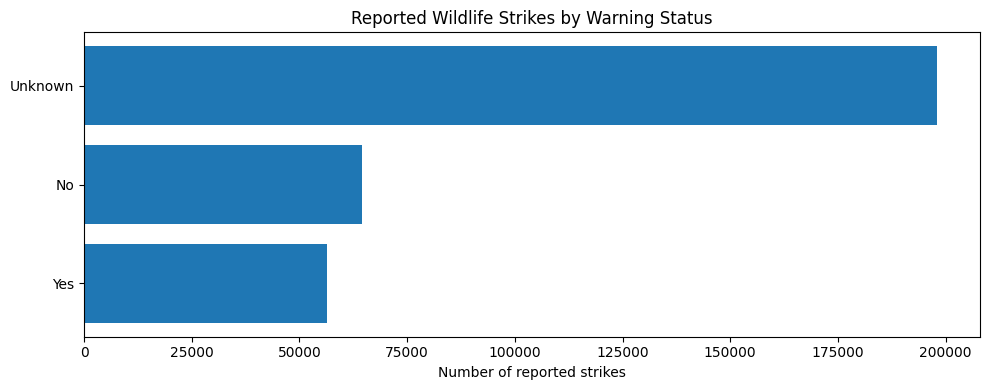

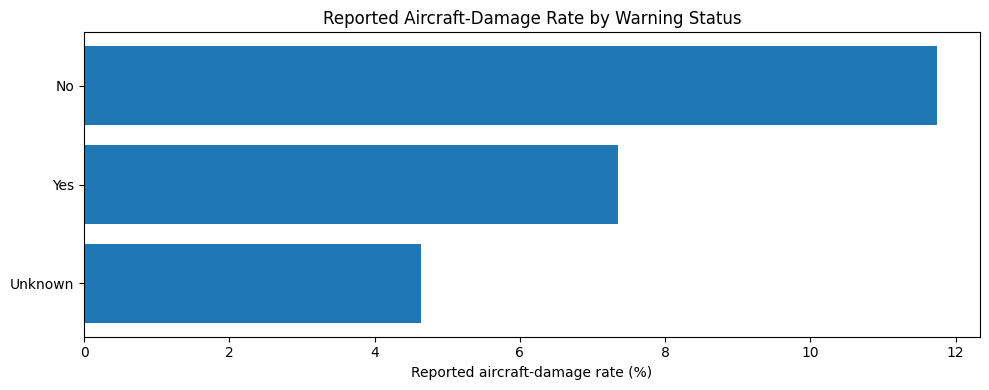

In [10]:

figure_specs = [
    ("temporal_season", "SEASON", "Season", None, 1),
    ("temporal_time_of_day", "TIME_OF_DAY", "Time of Day", None, 1),
    ("geographic_faa_region", "FAAREGION", "FAA Region", None, 50),
    ("wildlife_wildlife_type", "WILDLIFE_TYPE", "Broad Wildlife Type", None, 1),
    ("wildlife_wildlife_size", "SIZE", "Wildlife Size", None, 1),
    ("wildlife_number_struck", "NUM_STRUCK", "Number of Wildlife Struck", None, 1),
    ("aircraft_aircraft_class", "AC_CLASS", "Aircraft Class", None, 30),
    ("aircraft_aircraft_mass_group", "AC_MASS_GROUP", "Aircraft Mass Group", None, 1),
    ("aircraft_engine_type", "TYPE_ENG", "Engine Type", None, 30),
    ("aircraft_number_of_engines", "NUM_ENGS", "Number of Engines", None, 30),
    ("flight_phase_of_flight", "PHASE_OF_FLIGHT", "Phase of Flight", None, 30),
    ("flight_warning_status", "WARNED", "Warning Status", None, 1),
]

for key, column, label, top_n, minimum_records in figure_specs:
    if key not in summary_tables:
        continue
    plot_counts(
        summary_tables[key],
        column,
        f"Reported Wildlife Strikes by {label}",
        f"{key}_counts.png",
        top_n=top_n,
    )
    plot_damage_rates(
        summary_tables[key],
        column,
        f"Reported Aircraft-Damage Rate by {label}",
        f"{key}_damage_rate.png",
        top_n=top_n,
        minimum_records=minimum_records,
    )


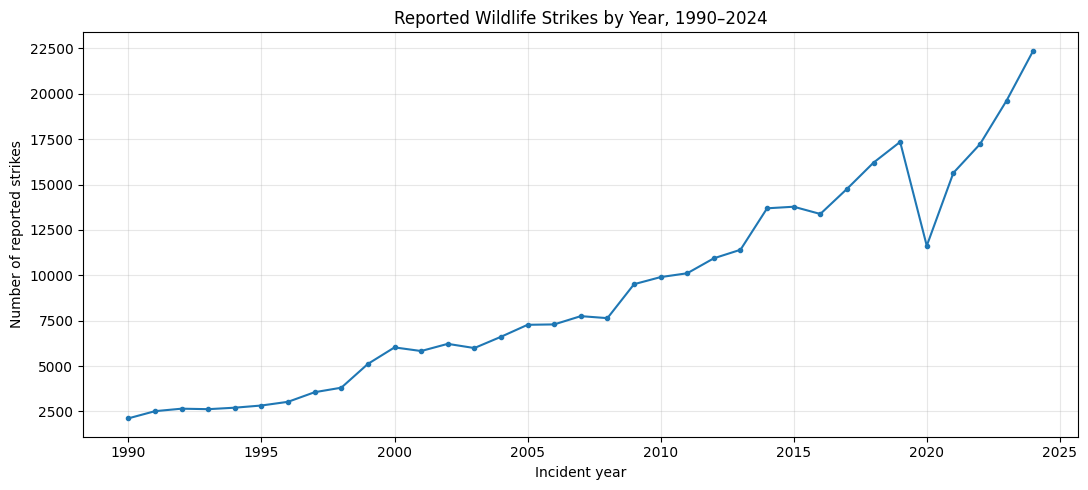

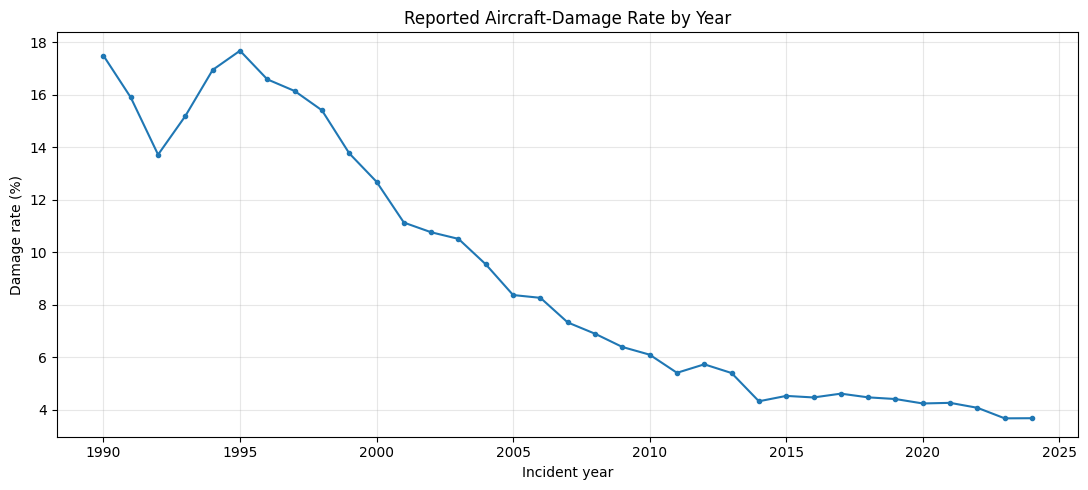

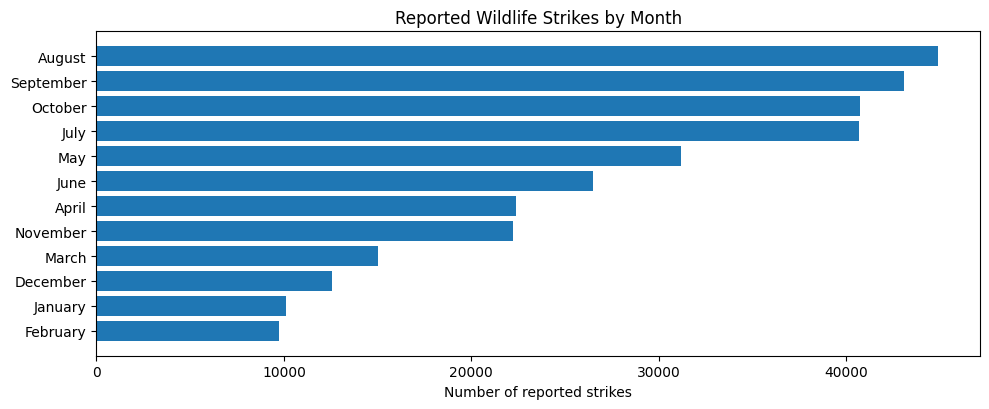

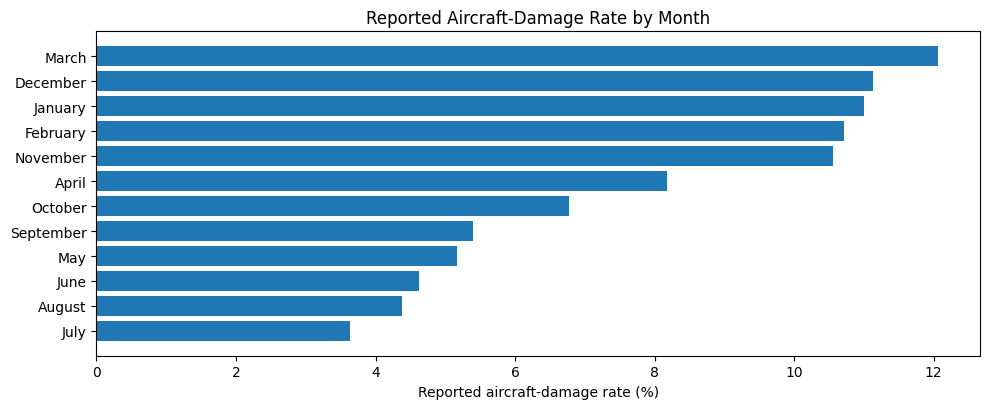

In [11]:

# Annual trend: separate count and rate figures.
yearly_summary = summary_tables["temporal_incident_year"].sort_values(
    "INCIDENT_YEAR"
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(yearly_summary["INCIDENT_YEAR"], yearly_summary["Reported_Strikes"], marker="o", markersize=3)
ax.set_title("Reported Wildlife Strikes by Year, 1990–2024")
ax.set_xlabel("Incident year")
ax.set_ylabel("Number of reported strikes")
ax.grid(alpha=0.3)
plt.tight_layout()
save_figure(fig, "temporal_annual_reported_strikes.png")
plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(yearly_summary["INCIDENT_YEAR"], yearly_summary["Damage_Rate_Pct"], marker="o", markersize=3)
ax.set_title("Reported Aircraft-Damage Rate by Year")
ax.set_xlabel("Incident year")
ax.set_ylabel("Damage rate (%)")
ax.grid(alpha=0.3)
plt.tight_layout()
save_figure(fig, "temporal_annual_damage_rate.png")
plt.show()

# Month labels are added only for communication.
month_names = {
    1: "January", 2: "February", 3: "March", 4: "April",
    5: "May", 6: "June", 7: "July", 8: "August",
    9: "September", 10: "October", 11: "November", 12: "December",
}
monthly_summary = summary_tables["temporal_incident_month"].copy()
monthly_summary["Month"] = monthly_summary["INCIDENT_MONTH"].map(month_names)
save_table(monthly_summary, "temporal_incident_month_labelled.csv")

plot_counts(
    monthly_summary,
    "Month",
    "Reported Wildlife Strikes by Month",
    "temporal_month_counts.png",
)
plot_damage_rates(
    monthly_summary,
    "Month",
    "Reported Aircraft-Damage Rate by Month",
    "temporal_month_damage_rate.png",
)


In [12]:
# Display annual temporal summary
display(
    yearly_summary[
        [
            "INCIDENT_YEAR",
            "Reported_Strikes",
            "Damage_Records",
            "No_Damage_Records",
            "Damage_Rate_Pct",
            "Damage_Rate_CI95_Lower",
            "Damage_Rate_CI95_Upper",
        ]
    ]
)

,INCIDENT_YEAR,Reported_Strikes,Damage_Records,No_Damage_Records,Damage_Rate_Pct,Damage_Rate_CI95_Lower,Damage_Rate_CI95_Upper
34,1990,2120,371,1749,17.5,15.941718,19.175854
33,1991,2515,400,2115,15.904573,14.527381,17.385765
31,1992,2652,364,2288,13.72549,12.468148,15.087772
32,1993,2625,399,2226,15.2,13.877472,16.624237
30,1994,2707,459,2248,16.95604,15.589488,18.416247
29,1995,2827,500,2327,17.686594,16.324180,19.136709
28,1996,3031,503,2528,16.595183,15.313138,17.961798
27,1997,3560,575,2985,16.151685,14.979382,17.396962
26,1998,3808,587,3221,15.414916,14.302921,16.596621
25,1999,5118,705,4413,13.774912,12.857839,14.746326


In [13]:
# Display monthly temporal summary
display(
    monthly_summary[
        [
            "INCIDENT_MONTH",
            "Month",
            "Reported_Strikes",
            "Damage_Records",
            "No_Damage_Records",
            "Damage_Rate_Pct",
            "Damage_Rate_CI95_Lower",
            "Damage_Rate_CI95_Upper",
        ]
    ]
)

,INCIDENT_MONTH,Month,Reported_Strikes,Damage_Records,No_Damage_Records,Damage_Rate_Pct,Damage_Rate_CI95_Lower,Damage_Rate_CI95_Upper
0,1,January,10121,1114,9007,11.006818,10.411796,11.631429
1,2,February,9732,1043,8689,10.717222,10.118065,11.347378
2,3,March,15000,1809,13191,12.06,11.548523,12.590906
3,4,April,22363,1828,20535,8.174216,7.822275,8.540525
4,5,May,31194,1610,29584,5.161249,4.921201,5.412339
5,6,June,26488,1223,25265,4.617185,4.370970,4.876563
6,7,July,40680,1480,39200,3.638151,3.460532,3.824526
7,8,August,44894,1964,42930,4.374749,4.189419,4.567887
8,9,September,43087,2327,40760,5.400701,5.191221,5.618133
9,10,October,40713,2759,37954,6.776705,6.536608,7.024958


### Temporal patterns

The annual number of reported wildlife strikes increased substantially from 1990 to 2024, with a sharp temporary decline in 2020 followed by a strong recovery to the highest recorded level in 2024. In contrast, the reported aircraft-damage rate generally declined over time, falling from approximately 17–18% in the early 1990s to below 4% in the most recent years.

Monthly patterns also show that strike frequency and damage consequences do not follow the same distribution. Reported strikes were most frequent from July to October, particularly in August and September, whereas the highest damage rates occurred during the colder months, especially March, December, January, and February. These results describe trends among reported strikes and may also reflect changes in reporting practices and operational conditions over time.

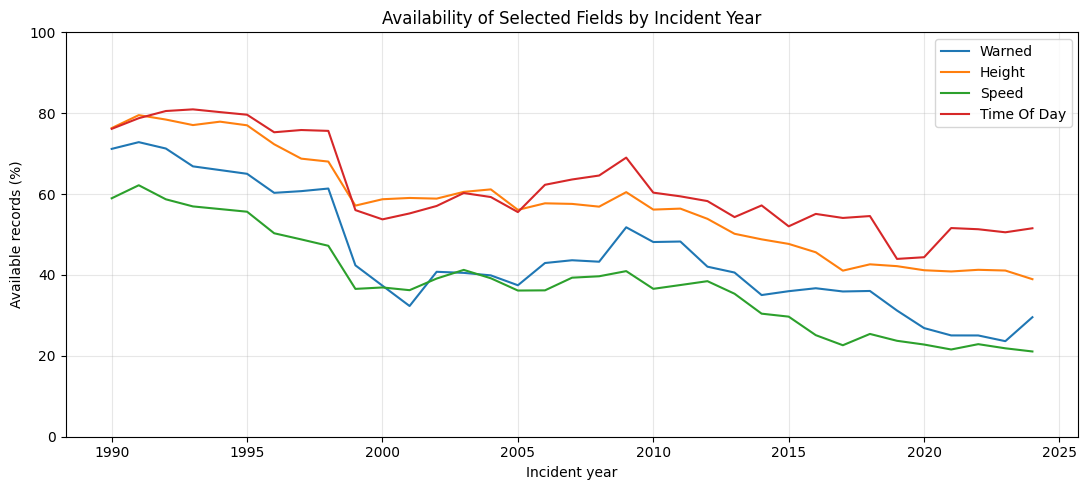

,INCIDENT_YEAR,Reported_Strikes,TIME_OF_DAY_Available_Pct,PHASE_OF_FLIGHT_Available_Pct,WARNED_Available_Pct,HEIGHT_Available_Pct,SPEED_Available_Pct,DISTANCE_Available_Pct,SKY_Available_Pct,PRECIPITATION_Available_Pct
25,2015,13777,52.028744,57.937142,35.987515,47.680917,29.694418,70.370908,45.096901,3.222763
26,2016,13378,55.097922,57.766482,36.716998,45.612199,25.115862,69.046195,46.030797,2.833009
27,2017,14756,54.100027,54.045812,35.917593,41.068040,22.621307,68.792356,42.132014,2.670100
28,2018,16206,54.566210,55.855856,36.042207,42.632358,25.416512,68.918919,39.929656,3.146983
29,2019,17348,43.970487,54.738298,31.202444,42.177773,23.720314,68.261471,39.284067,2.864884
30,2020,11625,44.387097,52.326882,26.864516,41.169892,22.795699,77.668817,39.122581,3.070968
31,2021,15641,51.601560,54.197302,25.049549,40.866952,21.571511,74.196023,38.904162,2.717218
32,2022,17223,51.309296,54.496894,25.042095,41.276200,22.887999,71.869012,41.131046,2.531499
33,2023,19625,50.552866,55.347771,23.628025,41.095541,21.864968,69.574522,40.626752,2.766879
34,2024,22371,51.548880,53.712396,29.556122,38.956685,21.080864,68.356354,39.765768,2.579232


In [14]:

availability_fields = [
    field for field in [
        "TIME_OF_DAY", "PHASE_OF_FLIGHT", "WARNED",
        "HEIGHT", "SPEED", "DISTANCE", "SKY", "PRECIPITATION"
    ] if field in analysis_df.columns
]
unavailable_labels_year = {
    "", "unknown", "not reported", "unk", "zzzz", "nan", "none"
}
availability_by_year_rows = []
for year, year_data in analysis_df.groupby("INCIDENT_YEAR", dropna=False):
    row = {"INCIDENT_YEAR": year, "Reported_Strikes": len(year_data)}
    for field in availability_fields:
        series = year_data[field]
        unavailable = series.isna()
        if (
            pd.api.types.is_object_dtype(series)
            or pd.api.types.is_string_dtype(series)
            or isinstance(series.dtype, pd.CategoricalDtype)
        ):
            normalized = series.astype("string").str.strip().str.lower()
            unavailable = unavailable | normalized.isin(unavailable_labels_year)
        row[f"{field}_Available_Pct"] = (1 - unavailable.mean()) * 100
    availability_by_year_rows.append(row)

availability_by_year = (
    pd.DataFrame(availability_by_year_rows)
    .sort_values("INCIDENT_YEAR")
    .reset_index(drop=True)
)
save_table(availability_by_year, "data_quality_availability_by_year.csv")

fig, ax = plt.subplots(figsize=(11, 5))
for field in ["WARNED", "HEIGHT", "SPEED", "TIME_OF_DAY"]:
    column = f"{field}_Available_Pct"
    if column in availability_by_year.columns:
        ax.plot(
            availability_by_year["INCIDENT_YEAR"],
            availability_by_year[column],
            label=field.replace("_", " ").title(),
        )
ax.set_title("Availability of Selected Fields by Incident Year")
ax.set_xlabel("Incident year")
ax.set_ylabel("Available records (%)")
ax.set_ylim(0, 100)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
save_figure(fig, "data_quality_selected_availability_by_year.png")
plt.show()
display(availability_by_year.tail(10))


### Reporting completeness over time

The availability of several contextual fields changed across the analytical period rather than remaining constant. This matters because a trend in reported damage or in a subgroup may partly reflect changes in what was recorded and which cases had complete contextual information.

The figure is a reporting-quality check, not a basis for deleting earlier records. Notebook 04 should consider year and missingness explicitly when assessing temporal associations, especially for warning status, height, speed, and time of day.


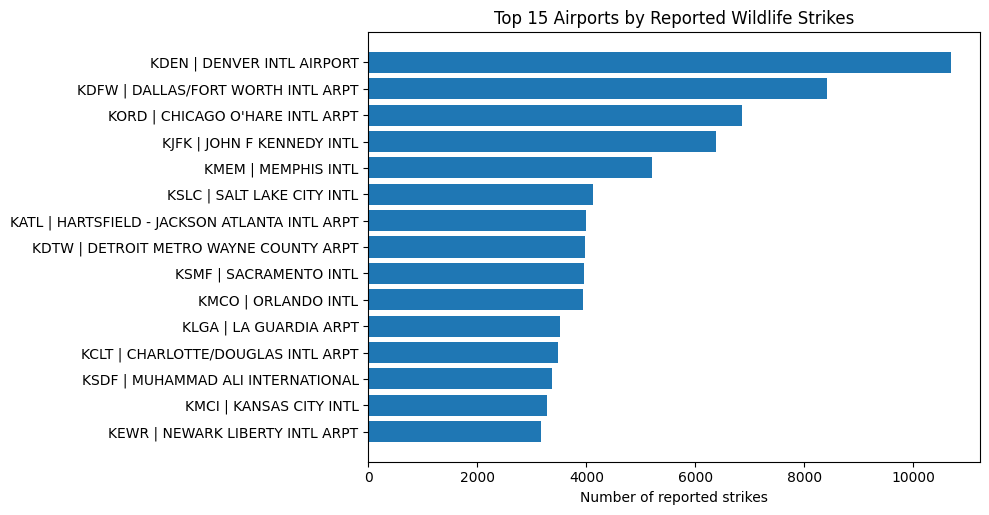

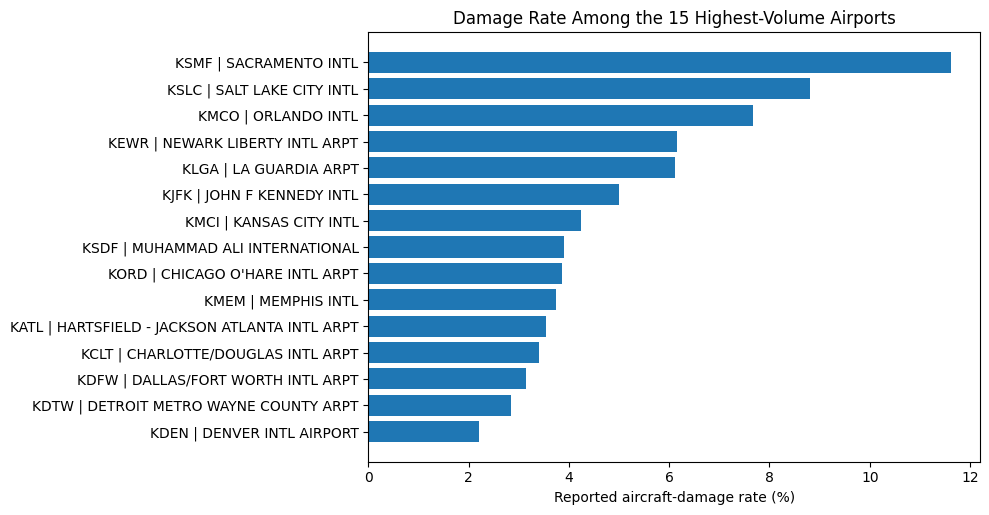

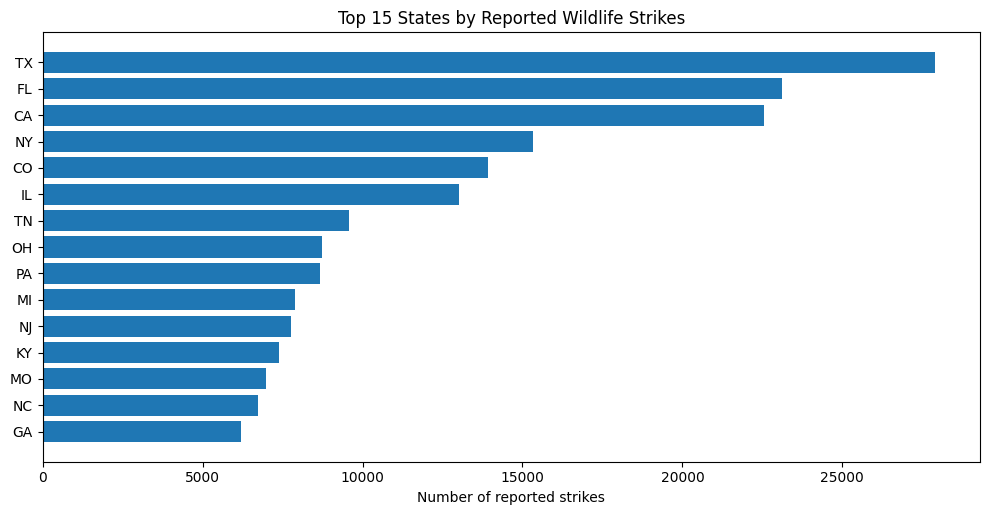

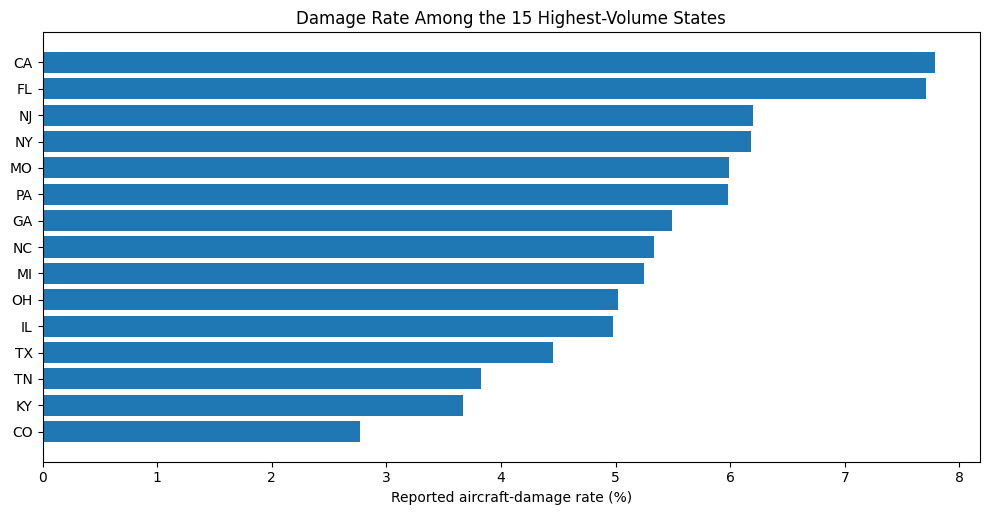

In [15]:

# High-cardinality figures: top categories by reporting volume.
if "geographic_airport" in summary_tables:
    valid_airports = summary_tables["geographic_airport"].copy()
    invalid_airport_ids = {"UNKNOWN", "UNK", "ZZZZ", "NOT REPORTED"}
    valid_airports = valid_airports.loc[
        ~valid_airports["AIRPORT_ID"]
        .astype("string")
        .str.strip()
        .str.upper()
        .isin(invalid_airport_ids)
    ]
    plot_counts(
        valid_airports,
        ["AIRPORT_ID", "AIRPORT"],
        "Top 15 Airports by Reported Wildlife Strikes",
        "geographic_top15_airports_counts.png",
        top_n=15,
    )
    plot_damage_rates(
        valid_airports,
        ["AIRPORT_ID", "AIRPORT"],
        "Damage Rate Among the 15 Highest-Volume Airports",
        "geographic_top15_airports_damage_rate.png",
        top_n=15,
        minimum_records=200,
    )

if "geographic_state" in summary_tables:
    state_summary = summary_tables["geographic_state"].copy()
    invalid_state_labels = {"UNKNOWN", "UNK", "NOT REPORTED"}
    state_summary = state_summary.loc[
        ~state_summary["STATE"]
        .astype("string")
        .str.strip()
        .str.upper()
        .isin(invalid_state_labels)
    ]
    plot_counts(
        state_summary,
        "STATE",
        "Top 15 States by Reported Wildlife Strikes",
        "geographic_top15_states_counts.png",
        top_n=15,
    )
    plot_damage_rates(
        state_summary,
        "STATE",
        "Damage Rate Among the 15 Highest-Volume States",
        "geographic_top15_states_damage_rate.png",
        top_n=15,
        minimum_records=200,
    )



### Geographic patterns

Reported strike volume and damage rate did not follow the same geographic pattern. Denver International recorded the largest number of strikes among the 15 highest-volume airports, but one of the lowest damage rates in this group. In contrast, Sacramento, Salt Lake City, and Orlando showed higher damage rates despite lower reporting volumes.

Texas, Florida, and California recorded the largest numbers of reported strikes. However, California and Florida had the highest damage rates among the 15 highest-volume states, while Texas had a comparatively lower rate. These results should not be interpreted as geographic risk because the analysis does not account for aircraft movements, airport size, or reporting differences.

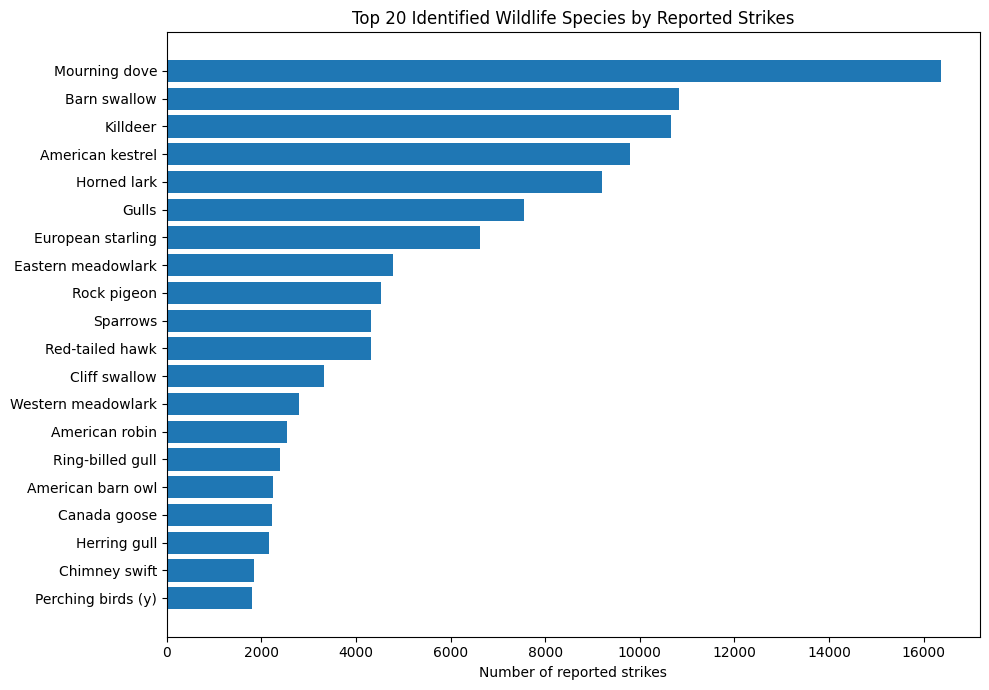

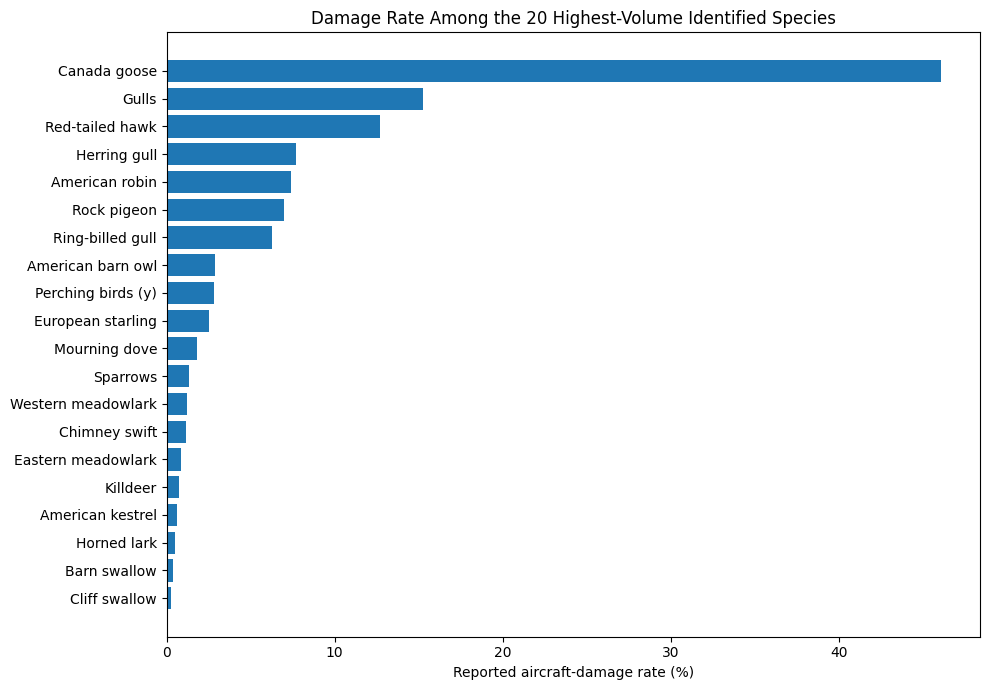

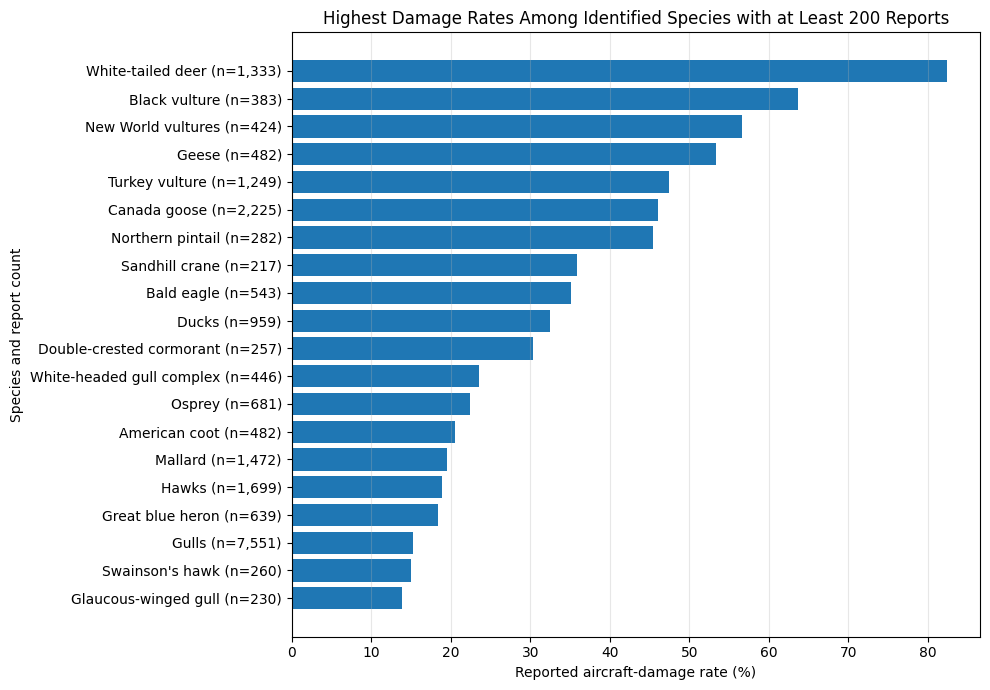

In [16]:

if "wildlife_exact_species" in summary_tables:
    species_summary = summary_tables["wildlife_exact_species"].copy()
    unknown_species = species_summary["SPECIES"].astype("string").str.contains(
        "unknown|not reported", case=False, na=False
    )
    identified_species = species_summary.loc[~unknown_species].copy()

    plot_counts(
        identified_species, "SPECIES",
        "Top 20 Identified Wildlife Species by Reported Strikes",
        "wildlife_top20_species_counts.png", top_n=20,
    )
    plot_damage_rates(
        identified_species, "SPECIES",
        "Damage Rate Among the 20 Highest-Volume Identified Species",
        "wildlife_top20_species_damage_rate.png",
        top_n=20, minimum_records=200,
    )

    supported_species = (
        identified_species.loc[identified_species["Reported_Strikes"] >= 200]
        .sort_values("Damage_Rate_Pct", ascending=False)
        .head(20).copy()
    )
    save_table(
        supported_species,
        "wildlife_top20_supported_species_by_damage_rate.csv",
    )

    fig, ax = plt.subplots(figsize=(10, 7))
    plot_data = supported_species.sort_values("Damage_Rate_Pct")
    labels = (
        plot_data["SPECIES"].astype(str)
        + " (n="
        + plot_data["Reported_Strikes"].map(lambda value: f"{value:,}")
        + ")"
    )
    ax.barh(labels, plot_data["Damage_Rate_Pct"])
    ax.set_title(
        "Highest Damage Rates Among Identified Species with at Least 200 Reports"
    )
    ax.set_xlabel("Reported aircraft-damage rate (%)")
    ax.set_ylabel("Species and report count")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    save_figure(fig, "wildlife_supported_species_highest_damage_rates.png")
    plt.show()


### Species patterns

The most frequently reported identified species were mourning doves, barn swallows, killdeer, and American kestrels. These common species all had relatively low damage rates. Gulls were an important exception because they appeared frequently and had a noticeably higher damage proportion.

A separate supported-species comparison changes the ranking. Among identified species with at least 200 reports, white-tailed deer had the highest damage rate, followed by black vultures, broader vulture and goose categories, turkey vultures, and Canada geese. The threshold prevents the ranking from being dominated by species observed only a handful of times, but it does not turn these comparisons into operational risk estimates.

Together, the two views show why frequency and consequence must be reported separately: the species most often recorded were not necessarily those with the largest proportion of reported aircraft damage.


## 7. Cross-factor descriptive analysis

This section examines how damage rates vary across selected combinations of wildlife, aircraft, seasonal, and flight characteristics. The results provide an initial view of possible interaction patterns. Notebook 04 should test the most defensible combinations before they are used to interpret later models.

In [17]:

interaction_tables = {}

def build_interaction_table(data, row_field, column_field, filename):
    required = {row_field, column_field, "INDEX_NR", "INDICATED_DAMAGE"}
    if not required.issubset(data.columns):
        warnings.warn(
            f"Skipping interaction {row_field} × {column_field}; "
            "one or more fields are unavailable."
        )
        return None

    table = (
        data.groupby([row_field, column_field], dropna=False)
        .agg(
            Reported_Strikes=("INDEX_NR", "size"),
            Damage_Records=("INDICATED_DAMAGE", "sum"),
        )
        .reset_index()
    )
    table["Damage_Rate_Pct"] = (
        table["Damage_Records"] / table["Reported_Strikes"] * 100
    )
    lower, upper = wilson_interval(
        table["Damage_Records"], table["Reported_Strikes"]
    )
    table["Damage_Rate_CI95_Lower"] = lower
    table["Damage_Rate_CI95_Upper"] = upper
    save_table(table, filename)
    interaction_tables[filename] = table
    return table

wildlife_season = build_interaction_table(
    analysis_df,
    "WILDLIFE_TYPE",
    "SEASON",
    "interaction_wildlife_type_by_season.csv",
)

size_mass = build_interaction_table(
    analysis_df,
    "SIZE",
    "AC_MASS_GROUP",
    "interaction_wildlife_size_by_aircraft_mass_group.csv",
)

size_phase = build_interaction_table(
    analysis_df,
    "SIZE",
    "PHASE_OF_FLIGHT",
    "interaction_wildlife_size_by_phase_of_flight.csv",
)

if {"AIRPORT_ID", "AIRPORT", "SEASON"}.issubset(analysis_df.columns):
    top_airport_ids = (
        analysis_df.loc[
            ~analysis_df["AIRPORT_ID"]
            .astype("string")
            .str.strip()
            .str.upper()
            .isin({"UNKNOWN", "UNK", "ZZZZ", "NOT REPORTED"})
        ]
        .groupby("AIRPORT_ID")
        .size()
        .nlargest(15)
        .index
    )
    top_airport_data = analysis_df.loc[
        analysis_df["AIRPORT_ID"].isin(top_airport_ids)
    ].copy()

    airport_season = (
        top_airport_data
        .groupby(["AIRPORT_ID", "AIRPORT", "SEASON"], dropna=False)
        .agg(
            Reported_Strikes=("INDEX_NR", "size"),
            Damage_Records=("INDICATED_DAMAGE", "sum"),
        )
        .reset_index()
    )
    airport_season["Damage_Rate_Pct"] = (
        airport_season["Damage_Records"]
        / airport_season["Reported_Strikes"]
        * 100
    )
    lower, upper = wilson_interval(
        airport_season["Damage_Records"],
        airport_season["Reported_Strikes"],
    )
    airport_season["Damage_Rate_CI95_Lower"] = lower
    airport_season["Damage_Rate_CI95_Upper"] = upper
    save_table(
        airport_season,
        "interaction_top15_airports_by_season.csv",
    )
    interaction_tables[
        "interaction_top15_airports_by_season.csv"
    ] = airport_season

if wildlife_season is not None:
    wildlife_season_pivot = wildlife_season.pivot_table(
        index="WILDLIFE_TYPE",
        columns="SEASON",
        values="Damage_Rate_Pct",
        aggfunc="first",
    )
    wildlife_season_pivot.to_csv(
        TABLE_DIR / "interaction_wildlife_type_by_season_damage_rate_matrix.csv"
    )
    output_manifest.append({
        "artifact_type": "table",
        "filename": "interaction_wildlife_type_by_season_damage_rate_matrix.csv",
        "relative_path": str(
            (
                TABLE_DIR
                / "interaction_wildlife_type_by_season_damage_rate_matrix.csv"
            ).relative_to(ROOT)
        ),
        "rows": len(wildlife_season_pivot),
        "columns": wildlife_season_pivot.shape[1],
    })
    display(wildlife_season_pivot)

if size_mass is not None:
    display(
        size_mass.sort_values(
            ["SIZE", "Reported_Strikes"],
            ascending=[True, False],
        )
    )

if size_phase is not None:
    display(
        size_phase.sort_values(
            ["SIZE", "Reported_Strikes"],
            ascending=[True, False],
        ).head(40)
    )


SEASON,Autumn,Spring,Summer,Winter
WILDLIFE_TYPE,,,,
Bat,1.162791,0.982318,0.751174,2.542373
Bird,6.704708,7.559836,3.946508,10.668758
Other wildlife,7.508785,7.685615,6.13611,11.47541
Reptile,0.0,0.990099,0.609756,0.0
Terrestrial mammal,28.713418,19.472789,20.229008,21.796165


,SIZE,AC_MASS_GROUP,Reported_Strikes,Damage_Records,Damage_Rate_Pct,Damage_Rate_CI95_Lower,Damage_Rate_CI95_Upper
0,Large,Heavy,7226,2341,32.3969,31.327448,33.485059
3,Large,Unknown,5271,50,0.948587,0.720293,1.248328
1,Large,Light,4461,2960,66.352836,64.952714,67.724817
2,Large,Medium,2643,1109,41.959894,40.091460,43.851667
4,Medium,Heavy,43122,5061,11.736469,11.436087,12.043667
7,Medium,Unknown,12847,79,0.61493,0.493724,0.765661
6,Medium,Medium,8467,1473,17.396953,16.604317,18.219160
5,Medium,Light,6874,2366,34.419552,33.305376,35.551133
8,Not reported,Heavy,22579,708,3.135657,2.916182,3.371076
10,Not reported,Medium,4227,229,5.417554,4.774732,6.141337


,SIZE,PHASE_OF_FLIGHT,Reported_Strikes,Damage_Records,Damage_Rate_Pct,Damage_Rate_CI95_Lower,Damage_Rate_CI95_Upper
0,Large,Approach,5423,2380,43.887147,42.571138,45.211811
8,Large,Not reported,5331,118,2.213468,1.851588,2.644171
6,Large,Landing Roll,2945,1167,39.626486,37.874535,41.405465
2,Large,Climb,2456,1341,54.600977,52.626228,56.561356
10,Large,Take-off Run,2188,706,32.26691,30.340565,34.255417
5,Large,En Route,737,575,78.018996,74.888101,80.859309
4,Large,Descent,196,99,50.510204,43.568358,57.432435
11,Large,Taxi,118,19,16.101695,10.557198,23.783782
7,Large,Local,105,27,25.714286,18.315792,34.827124
3,Large,Departure,68,18,26.470588,17.449603,38.007959


### Cross-factor patterns

Damage patterns differed by wildlife type and season rather than following a single seasonal pattern. Birds, bats, and `Other wildlife` had their highest reported damage proportions in winter, whereas terrestrial mammals reached their highest rate in autumn. Terrestrial mammals had the highest broad-group damage proportion in every season. Among the remaining groups, `Other wildlife` was slightly higher than birds across all four seasons, while bats and reptiles had much lower rates. Reptile estimates are based on relatively small numbers of reports and should therefore be interpreted cautiously.

Among records with known aircraft mass, damage rates increased with wildlife size and were consistently highest for light aircraft. For large-wildlife strikes, the damage rate was 66.4% for light aircraft, 42.0% for medium aircraft, and 32.4% for heavy aircraft. The very low rates in the `Unknown` aircraft-mass group likely reflect missing or incomplete aircraft information and should not be interpreted as lower risk.

The pattern also varied across phases of flight. Large-wildlife strikes had particularly high damage rates during en route, climb, descent, and approach, while small-wildlife strikes generally had much lower rates. These results highlight possible interaction patterns for further modelling, but they remain descriptive and do not establish causal or independent effects.

In [18]:
def plot_damage_rate_heatmap(
    table,
    row_field,
    column_field,
    title,
    filename,
    row_order=None,
    column_order=None,
):
    plot_data = table.copy()

    # Exclude unavailable categories from the figure only.
    unavailable = {"Unknown", "Not reported"}

    plot_data = plot_data.loc[
        ~plot_data[row_field].astype(str).isin(unavailable)
        & ~plot_data[column_field].astype(str).isin(unavailable)
    ]

    matrix = plot_data.pivot_table(
        index=row_field,
        columns=column_field,
        values="Damage_Rate_Pct",
        aggfunc="first",
    )

    if row_order is not None:
        valid_rows = [
            value for value in row_order
            if value in matrix.index
        ]
        matrix = matrix.reindex(valid_rows)

    if column_order is not None:
        valid_columns = [
            value for value in column_order
            if value in matrix.columns
        ]
        matrix = matrix.reindex(columns=valid_columns)

    fig, ax = plt.subplots(
        figsize=(
            max(8, matrix.shape[1] * 1.2),
            max(4, matrix.shape[0] * 0.7),
        )
    )

    image = ax.imshow(
        matrix.to_numpy(dtype=float),
        aspect="auto",
    )

    ax.set_xticks(range(matrix.shape[1]))
    ax.set_xticklabels(
        matrix.columns,
        rotation=45,
        ha="right",
    )

    ax.set_yticks(range(matrix.shape[0]))
    ax.set_yticklabels(matrix.index)

    # Display the damage rate inside each cell.
    for row_position in range(matrix.shape[0]):
        for column_position in range(matrix.shape[1]):
            value = matrix.iloc[
                row_position,
                column_position
            ]

            if pd.notna(value):
                ax.text(
                    column_position,
                    row_position,
                    f"{value:.1f}%",
                    ha="center",
                    va="center",
                )

    ax.set_title(title)
    ax.set_xlabel(column_field.replace("_", " ").title())
    ax.set_ylabel(row_field.replace("_", " ").title())

    fig.colorbar(
        image,
        ax=ax,
        label="Reported aircraft-damage rate (%)",
    )

    plt.tight_layout()
    save_figure(fig, filename)
    plt.show()

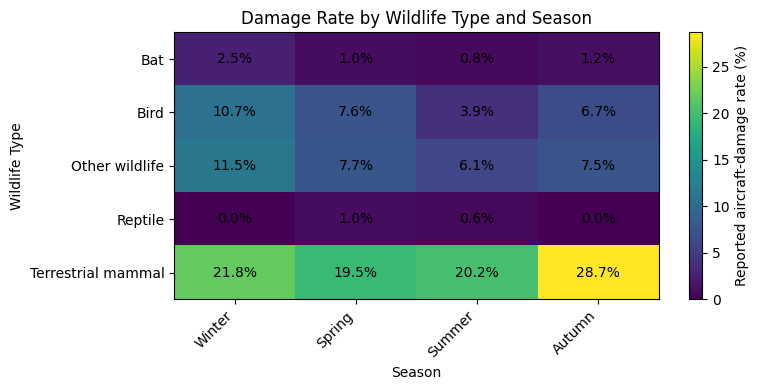

In [19]:
plot_damage_rate_heatmap(
    wildlife_season,
    row_field="WILDLIFE_TYPE",
    column_field="SEASON",
    title="Damage Rate by Wildlife Type and Season",
    filename="interaction_wildlife_type_by_season_heatmap.png",
    column_order=[
        "Winter",
        "Spring",
        "Summer",
        "Autumn",
    ],
)

Damage rates were generally highest in winter and lowest in summer. Terrestrial mammals and birds showed the highest rates across seasons, while bats and reptiles had much lower rates. Results for low-volume wildlife groups should be interpreted cautiously.

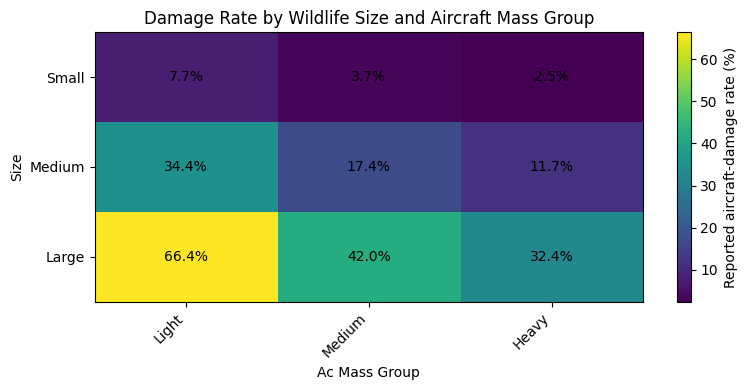

In [20]:
plot_damage_rate_heatmap(
    size_mass,
    row_field="SIZE",
    column_field="AC_MASS_GROUP",
    title="Damage Rate by Wildlife Size and Aircraft Mass Group",
    filename="interaction_size_by_aircraft_mass_heatmap.png",
    row_order=[
        "Small",
        "Medium",
        "Large",
    ],
    column_order=[
        "Light",
        "Medium",
        "Heavy",
    ],
)

Damage rates increased with wildlife size across all aircraft mass groups. Within each wildlife-size category, light aircraft consistently had higher damage rates than medium and heavy aircraft, with the largest difference observed for large-wildlife strikes.

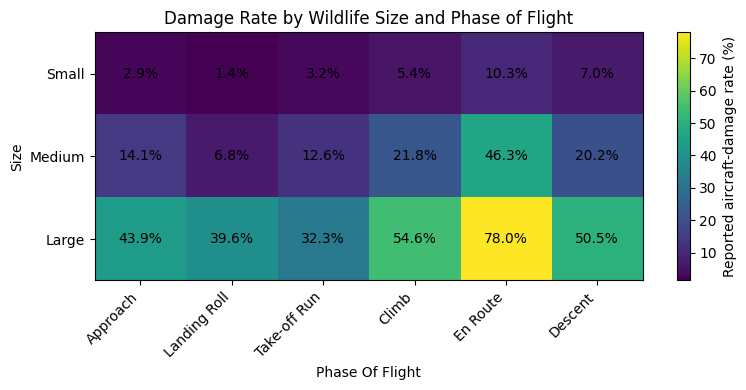

In [21]:
main_phases = [
    "Approach",
    "Landing Roll",
    "Take-off Run",
    "Climb",
    "En Route",
    "Descent",
]

size_phase_figure = size_phase.loc[
    size_phase["PHASE_OF_FLIGHT"].isin(main_phases)
].copy()

plot_damage_rate_heatmap(
    size_phase_figure,
    row_field="SIZE",
    column_field="PHASE_OF_FLIGHT",
    title="Damage Rate by Wildlife Size and Phase of Flight",
    filename="interaction_size_by_flight_phase_heatmap.png",
    row_order=[
        "Small",
        "Medium",
        "Large",
    ],
    column_order=main_phases,
)

Damage rates increased consistently with wildlife size across all selected phases of flight. En-route strikes showed the highest rates, reaching 78.0% for large wildlife and 46.3% for medium wildlife, while climb and descent also showed elevated rates. However, some phase–size combinations had fewer records, so these descriptive patterns should be reviewed together with their confidence intervals and should not be interpreted as causal effects.

## 8. Numerical flight-context analysis

This section compares recorded height, speed, and distance overall and by damage status. Missing values and unusual observations identified in Notebook 02 are kept for review rather than removed automatically.

In [22]:

numeric_fields = [
    field for field in ["HEIGHT", "SPEED", "DISTANCE"]
    if field in analysis_df.columns
]

numeric_overall_rows = []
numeric_by_damage_rows = []

for field in numeric_fields:
    values = pd.to_numeric(analysis_df[field], errors="coerce")

    numeric_overall_rows.append({
        "Variable": field,
        "Available_Records": int(values.notna().sum()),
        "Missing_Records": int(values.isna().sum()),
        "Missing_Percentage": values.isna().mean() * 100,
        "Mean": values.mean(),
        "Standard_Deviation": values.std(),
        "Minimum": values.min(),
        "P25": values.quantile(0.25),
        "Median": values.median(),
        "P75": values.quantile(0.75),
        "P99": values.quantile(0.99),
        "Maximum": values.max(),
    })

    for damage_value, label in [(0, "No damage reported"), (1, "Damage reported")]:
        group_values = values.loc[
            analysis_df["INDICATED_DAMAGE"].eq(damage_value)
        ].dropna()
        numeric_by_damage_rows.append({
            "Variable": field,
            "Damage_Status": label,
            "Available_Records": len(group_values),
            "Mean": group_values.mean(),
            "Standard_Deviation": group_values.std(),
            "P25": group_values.quantile(0.25),
            "Median": group_values.median(),
            "P75": group_values.quantile(0.75),
        })

numeric_overall_summary = pd.DataFrame(numeric_overall_rows)
numeric_by_damage_summary = pd.DataFrame(numeric_by_damage_rows)

save_table(numeric_overall_summary, "flight_numeric_overall_summary.csv")
save_table(numeric_by_damage_summary, "flight_numeric_summary_by_damage.csv")

display(numeric_overall_summary)
display(numeric_by_damage_summary)


,Variable,Available_Records,Missing_Records,Missing_Percentage,Mean,Standard_Deviation,Minimum,P25,Median,P75,P99,Maximum
0,HEIGHT,160917,158190,49.572714,876.909289,1853.047706,0.0,0.0,50.0,900.0,9000.0,32000.0
1,SPEED,100786,218321,68.416237,142.831088,46.456937,0.0,120.0,140.0,160.0,250.0,541.0
2,DISTANCE,212053,107054,33.547995,0.854350,3.648005,0.0,0.0,0.0,0.0,20.0,99.0


,Variable,Damage_Status,Available_Records,Mean,Standard_Deviation,P25,Median,P75
0,HEIGHT,No damage reported,145111,824.013093,1775.665320,0.0,25.0,800.0
1,HEIGHT,Damage reported,15806,1362.536252,2398.030904,0.0,400.0,1700.0
2,SPEED,No damage reported,89058,143.001100,45.382554,120.0,140.0,160.0
3,SPEED,Damage reported,11728,141.540075,53.906112,100.0,135.0,170.0
4,DISTANCE,No damage reported,202314,0.779367,3.448310,0.0,0.0,0.0
5,DISTANCE,Damage reported,9739,2.412029,6.340903,0.0,0.0,1.0


In [23]:
def plot_numeric_by_damage(data, variable, title, filename):
    plot_data = data[[variable, "INDICATED_DAMAGE"]].copy()

    plot_data[variable] = pd.to_numeric(
        plot_data[variable],
        errors="coerce"
    )

    plot_data = plot_data.dropna(
        subset=[variable, "INDICATED_DAMAGE"]
    )

    # Limit the displayed range to P99 for readability only.
    upper_limit = plot_data[variable].quantile(0.99)

    figure_data = plot_data.loc[
        plot_data[variable] <= upper_limit
    ].copy()

    figure_data["Damage_Status"] = (
        figure_data["INDICATED_DAMAGE"]
        .map({
            0: "No damage reported",
            1: "Damage reported",
        })
    )

    fig, ax = plt.subplots(figsize=(7, 4))

    figure_data.boxplot(
        column=variable,
        by="Damage_Status",
        ax=ax,
        grid=False,
    )

    ax.set_title(title)
    ax.set_xlabel("Damage status")
    ax.set_ylabel(variable.replace("_", " ").title())

    fig.suptitle("")
    plt.tight_layout()

    save_figure(fig, filename)
    plt.show()

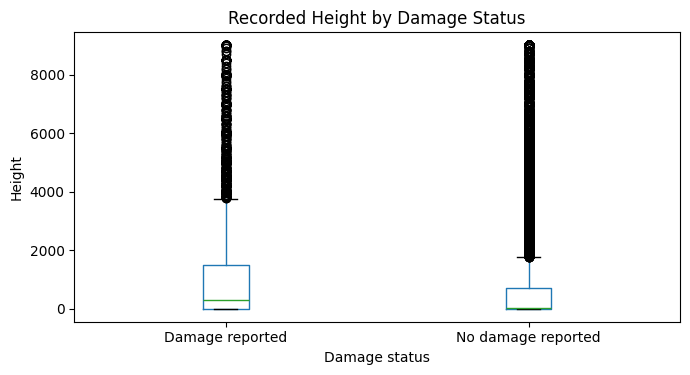

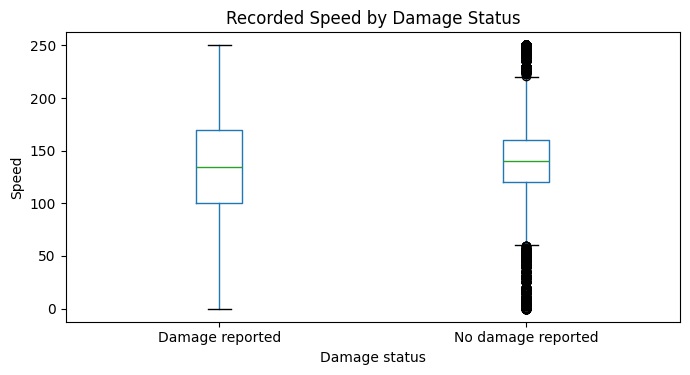

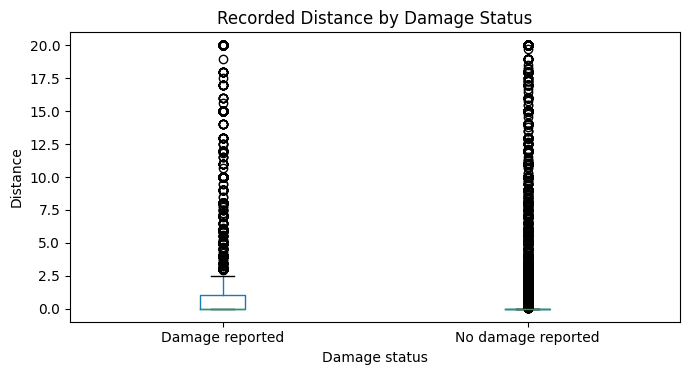

In [24]:
plot_numeric_by_damage(
    analysis_df,
    variable="HEIGHT",
    title="Recorded Height by Damage Status",
    filename="flight_height_by_damage_status.png",
)

plot_numeric_by_damage(
    analysis_df,
    variable="SPEED",
    title="Recorded Speed by Damage Status",
    filename="flight_speed_by_damage_status.png",
)

plot_numeric_by_damage(
    analysis_df,
    variable="DISTANCE",
    title="Recorded Distance by Damage Status",
    filename="flight_distance_by_damage_status.png",
)

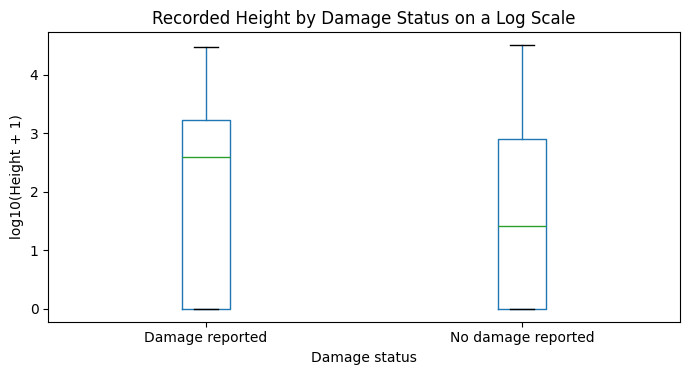

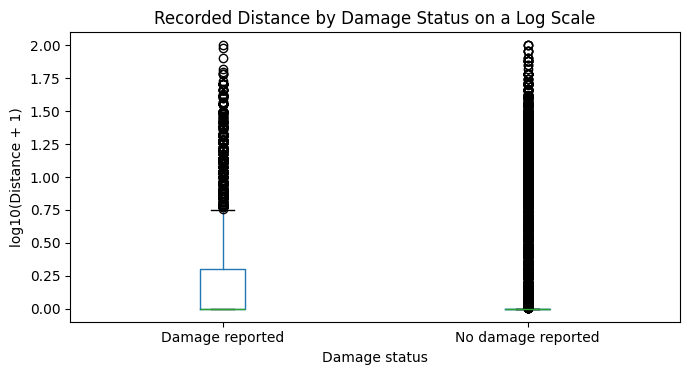


HEIGHT bands


,HEIGHT_BAND,Reported_Strikes,Damage_Records,No_Damage_Records,Damage_Rate_Pct,Damage_Rate_CI95_Lower,Damage_Rate_CI95_Upper
0,0,68798,4531,64267,6.585947,6.403015,6.773728
1,1–100,25324,2180,23144,8.608435,8.269216,8.960209
2,"1,501–5,000",21789,3133,18656,14.378815,13.919196,14.850992
3,101–500,20232,2039,18193,10.078094,9.670824,10.500522
4,"501–1,500",18741,2954,15787,15.762233,15.247554,16.290944
5,"More than 5,000",6033,969,5064,16.061661,15.156760,17.009756



SPEED bands


,SPEED_BAND,Reported_Strikes,Damage_Records,No_Damage_Records,Damage_Rate_Pct,Damage_Rate_CI95_Lower,Damage_Rate_CI95_Upper
0,101–150,53282,4913,48369,9.22075,8.978017,9.469363
1,100 or less,18281,2989,15292,16.350309,15.821282,16.893476
2,151–200,17618,2249,15369,12.765354,12.280694,13.266248
3,More than 200,11605,1577,10028,13.58897,12.977542,14.224497



DISTANCE bands


,DISTANCE_BAND,Reported_Strikes,Damage_Records,No_Damage_Records,Damage_Rate_Pct,Damage_Rate_CI95_Lower,Damage_Rate_CI95_Upper
0,0,185839,6712,179127,3.611728,3.527851,3.697523
1,More than 1–5,10356,1148,9208,11.085361,10.495057,11.704526
2,More than 5,9988,1257,8731,12.585102,11.948967,13.250007
3,More than 0–1,5870,622,5248,10.596252,9.834467,11.409579


In [25]:

def plot_log1p_numeric_by_damage(data, variable, title, filename):
    plot_data = data[[variable, "INDICATED_DAMAGE"]].copy()
    plot_data[variable] = pd.to_numeric(plot_data[variable], errors="coerce")
    plot_data = plot_data.dropna(subset=[variable, "INDICATED_DAMAGE"])
    plot_data = plot_data.loc[plot_data[variable] >= 0].copy()
    plot_data["log10_value_plus_1"] = np.log10(plot_data[variable] + 1)
    plot_data["Damage_Status"] = plot_data["INDICATED_DAMAGE"].map({
        0: "No damage reported", 1: "Damage reported"
    })
    fig, ax = plt.subplots(figsize=(7, 4))
    plot_data.boxplot(
        column="log10_value_plus_1", by="Damage_Status", ax=ax, grid=False
    )
    ax.set_title(title)
    ax.set_xlabel("Damage status")
    ax.set_ylabel(f"log10({variable.title()} + 1)")
    fig.suptitle("")
    plt.tight_layout()
    save_figure(fig, filename)
    plt.show()

for variable, title, filename in [
    ("HEIGHT", "Recorded Height by Damage Status on a Log Scale",
     "flight_height_log10p1_by_damage_status.png"),
    ("DISTANCE", "Recorded Distance by Damage Status on a Log Scale",
     "flight_distance_log10p1_by_damage_status.png"),
]:
    if variable in analysis_df.columns:
        plot_log1p_numeric_by_damage(analysis_df, variable, title, filename)

numeric_bin_specs = {
    "HEIGHT": (
        [-np.inf, 0, 100, 500, 1500, 5000, np.inf],
        ["0", "1–100", "101–500", "501–1,500", "1,501–5,000", "More than 5,000"],
        "flight_height_bands.csv",
    ),
    "SPEED": (
        [-np.inf, 100, 150, 200, np.inf],
        ["100 or less", "101–150", "151–200", "More than 200"],
        "flight_speed_bands.csv",
    ),
    "DISTANCE": (
        [-np.inf, 0, 1, 5, np.inf],
        ["0", "More than 0–1", "More than 1–5", "More than 5"],
        "flight_distance_bands.csv",
    ),
}
numeric_band_tables = {}
for variable, (bins, labels, filename) in numeric_bin_specs.items():
    if variable not in analysis_df.columns:
        continue
    values = pd.to_numeric(analysis_df[variable], errors="coerce")
    band = pd.cut(values, bins=bins, labels=labels, include_lowest=True)
    temporary = analysis_df[["INDEX_NR", "INDICATED_DAMAGE"]].copy()
    temporary[f"{variable}_BAND"] = band
    temporary = temporary.dropna(subset=[f"{variable}_BAND"])
    table = outcome_by_category(temporary, f"{variable}_BAND")
    table[f"{variable}_BAND"] = table[f"{variable}_BAND"].astype("string")
    numeric_band_tables[variable] = table
    save_table(table, filename)
    print(f"\n{variable} bands")
    display(table)


### Numerical flight-context patterns

Height, speed, and distance had substantial missingness, especially speed (68.4%) and height (49.6%). Their descriptive patterns therefore apply only to records containing those measurements.

Damaging strikes were recorded at higher altitudes than non-damaging strikes: the median was 400 feet for damaging records and 25 feet for non-damaging records. Recorded distance was also more dispersed among damaging incidents, although the median remained zero in both groups. Speed differed much less at the median—135 knots for damaging reports and 140 knots for non-damaging reports—so the notebook does not describe speed as having a simple increasing relationship with damage.

The ordinary-scale summaries preserve the original units. Supplemental `log10(value + 1)` figures are included for height and distance because both variables contain zero values and long right tails. The transformation compresses extreme values and makes the central distributions easier to compare; it does not change the observations or replace the raw-unit summaries. Speed is not log-transformed because its distribution is much less skewed.

Binned tables provide an additional view in the original units. These cut-points are descriptive communication choices, not statistically learned thresholds. Notebook 04 should test whether the observed differences remain after accounting for missingness, year, aircraft, wildlife, and flight context.


## 9. Secondary consequence analysis

This section summarizes damage severity, affected aircraft components, and reported injuries and fatalities. Because these variables describe consequences observed after a strike, they are excluded from the predictors used in the primary binary damage model to prevent data leakage. Cost variables were not analyzed because their formats had not yet been fully converted and validated.

,DAMAGE_LEVEL,Damage_Records,Severity,Percentage_Among_Damaged
0,M,8657,Minor,41.405204
1,M?,7818,Damage reported; level undetermined,37.392386
2,S,4344,Substantial,20.776736
3,D,89,Destroyed,0.425674


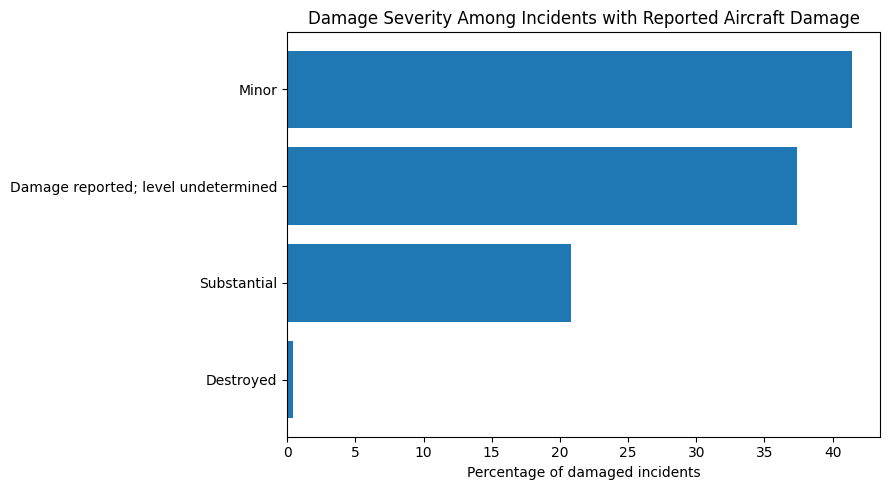

,Component_Field,Damage_Records,Percentage_of_All_Reported_Strikes
8,DAM_WING_ROT,6296,1.973006
3,DAM_ENG1,3085,0.966760
4,DAM_ENG2,2602,0.815400
13,DAM_OTHER,2455,0.769334
0,DAM_RAD,2105,0.659653
2,DAM_NOSE,1763,0.552479
1,DAM_WINDSHLD,1468,0.460034
10,DAM_LG,1308,0.409894
9,DAM_FUSE,1209,0.378870
11,DAM_TAIL,1052,0.329670


,Impact,Incidents_with_Positive_Value,Total_Reported_Value
0,Reported injuries,294,376.0
1,Reported fatalities,25,52.0


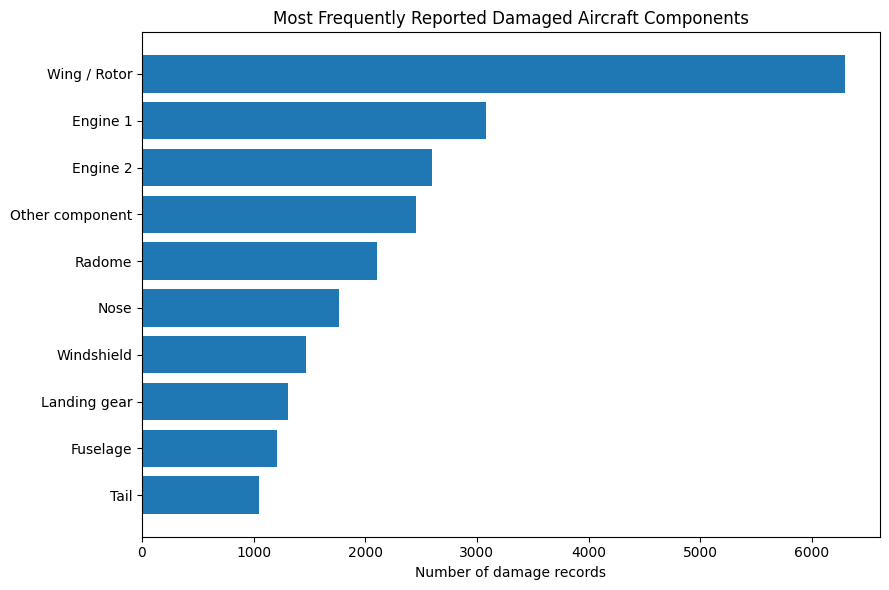

In [26]:

# Severity among damaged incidents only.
severity_labels = {
    "N": "No-damage severity code (target conflict)",
    "M": "Minor",
    "M?": "Damage reported; level undetermined",
    "S": "Substantial",
    "D": "Destroyed",
}

if "DAMAGE_LEVEL" in analysis_df.columns:
    damaged_df = analysis_df.loc[
        analysis_df["INDICATED_DAMAGE"].eq(1)
    ].copy()

    severity_summary = (
        damaged_df["DAMAGE_LEVEL"]
        .value_counts(dropna=False)
        .rename_axis("DAMAGE_LEVEL")
        .reset_index(name="Damage_Records")
    )
    severity_summary["Severity"] = (
        severity_summary["DAMAGE_LEVEL"]
        .map(severity_labels)
        .fillna(severity_summary["DAMAGE_LEVEL"].astype("string"))
    )
    severity_summary["Percentage_Among_Damaged"] = (
        severity_summary["Damage_Records"]
        / severity_summary["Damage_Records"].sum()
        * 100
    )
    save_table(severity_summary, "consequence_damage_severity_among_damaged.csv")
    display(severity_summary)

    plot_severity = severity_summary.sort_values(
        "Percentage_Among_Damaged", ascending=True
    )
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(
        plot_severity["Severity"],
        plot_severity["Percentage_Among_Damaged"]
    )
    ax.set_title("Damage Severity Among Incidents with Reported Aircraft Damage")
    ax.set_xlabel("Percentage of damaged incidents")
    ax.set_ylabel("")
    plt.tight_layout()
    save_figure(fig, "consequence_damage_severity_among_damaged.png")
    plt.show()

# Component outcomes.
component_columns = [
    column for column in analysis_df.columns
    if column.startswith("DAM_")
    and not column.endswith(("_RAW", "_FLAG"))
]

if component_columns:
    component_summary = pd.DataFrame({
        "Component_Field": component_columns,
        "Damage_Records": [
            pd.to_numeric(analysis_df[column], errors="coerce")
            .fillna(0)
            .sum()
            for column in component_columns
        ],
    }).sort_values("Damage_Records", ascending=False)
    component_summary["Percentage_of_All_Reported_Strikes"] = (
        component_summary["Damage_Records"] / len(analysis_df) * 100
    )
    save_table(component_summary, "consequence_component_damage_summary.csv")
    display(component_summary)

# Operational, human, and cost outputs when present.
if "EFFECT" in analysis_df.columns:
    effect_summary = (
        analysis_df["EFFECT"]
        .fillna("Not reported")
        .astype("string")
        .value_counts(dropna=False)
        .rename_axis("Effect")
        .reset_index(name="Reported_Records")
    )
    effect_summary["Percentage_of_All_Records"] = (
        effect_summary["Reported_Records"] / len(analysis_df) * 100
    )
    save_table(effect_summary, "consequence_operational_effects.csv")

impact_rows = []
for field, label in [
    ("NR_INJURIES", "Reported injuries"),
    ("NR_FATALITIES", "Reported fatalities"),
]:
    if field in analysis_df.columns:
        values = pd.to_numeric(analysis_df[field], errors="coerce").fillna(0)
        impact_rows.append({
            "Impact": label,
            "Incidents_with_Positive_Value": int((values > 0).sum()),
            "Total_Reported_Value": values.sum(),
        })
if impact_rows:
    impact_summary = pd.DataFrame(impact_rows)
    save_table(impact_summary, "consequence_injuries_fatalities.csv")
    display(impact_summary)

cost_rows = []
for field, label in [
    ("COST_REPAIRS_INFL_ADJ", "Inflation-adjusted repair cost"),
    ("COST_OTHER_INFL_ADJ", "Inflation-adjusted other cost"),
]:
    if field in analysis_df.columns:
        values = pd.to_numeric(analysis_df[field], errors="coerce")
        positive = values.loc[values > 0]
        cost_rows.append({
            "Cost_Field": field,
            "Cost_Category": label,
            "Positive_Cost_Records": int(positive.count()),
            "Total_USD": positive.sum(),
            "Median_USD": positive.median(),
            "Mean_USD": positive.mean(),
            "P95_USD": positive.quantile(0.95),
            "Maximum_USD": positive.max(),
        })

# Create clearer component labels for the figure.
component_label_map = {
    "DAM_WING_ROT": "Wing / Rotor",
    "DAM_ENG1": "Engine 1",
    "DAM_ENG2": "Engine 2",
    "DAM_ENG3": "Engine 3",
    "DAM_ENG4": "Engine 4",
    "DAM_OTHER": "Other component",
    "DAM_RAD": "Radome",
    "DAM_NOSE": "Nose",
    "DAM_WINDSHLD": "Windshield",
    "DAM_LG": "Landing gear",
    "DAM_FUSE": "Fuselage",
    "DAM_TAIL": "Tail",
    "DAM_LGHTS": "Lights",
    "DAM_PROP": "Propeller",
}

component_plot = component_summary.copy()

component_plot["Component"] = (
    component_plot["Component_Field"]
    .map(component_label_map)
    .fillna(
        component_plot["Component_Field"]
        .str.replace("DAM_", "", regex=False)
        .str.replace("_", " ", regex=False)
        .str.title()
    )
)

# Display the 10 most frequently recorded damaged components.
component_plot = (
    component_plot
    .nlargest(10, "Damage_Records")
    .sort_values("Damage_Records", ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(
    component_plot["Component"],
    component_plot["Damage_Records"]
)

ax.set_title("Most Frequently Reported Damaged Aircraft Components")
ax.set_xlabel("Number of damage records")
ax.set_ylabel("")

plt.tight_layout()

save_figure(
    fig,
    "consequence_top10_component_damage.png"
)

plt.show()


### Secondary consequence patterns

Among the 20,908 incidents with reported aircraft damage, 41.4% were classified as minor and 20.8% as substantial, while destroyed aircraft accounted for only 0.4%. However, the damage level was undetermined in 37.4% of damaged records, which may limit the development of a detailed severity model.

Wing or rotor damage was the most frequently recorded component outcome, followed by damage to the first and second engines. Component fields are not mutually exclusive because one incident may involve damage to more than one aircraft component.

Injuries and fatalities were uncommon, with 294 incidents reporting injuries and 25 reporting fatalities. Cost fields were excluded because they had not yet been converted and validated reliably.

## 10. Predictor availability and data quality

This section evaluates the availability of key predictors used for RQ1. Explicit `Unknown` and `Not reported` categories are treated as unavailable in this availability summary, but they remain visible as separate categories in the descriptive association tables.

,Variable,Available_Records,Unavailable_Records,Unavailable_Percentage
0,PRECIPITATION,11969,307138,96.249220
1,SPEED,100786,218321,68.416237
2,WARNED,121015,198092,62.076984
3,SKY,151325,167782,52.578602
4,HEIGHT,160917,158190,49.572714
5,TIME_OF_DAY,180459,138648,43.448749
6,PHASE_OF_FLIGHT,194586,124521,39.021707
7,DISTANCE,212053,107054,33.547995
8,TYPE_ENG,227849,91258,28.597931
9,NUM_ENGS,227893,91214,28.584143


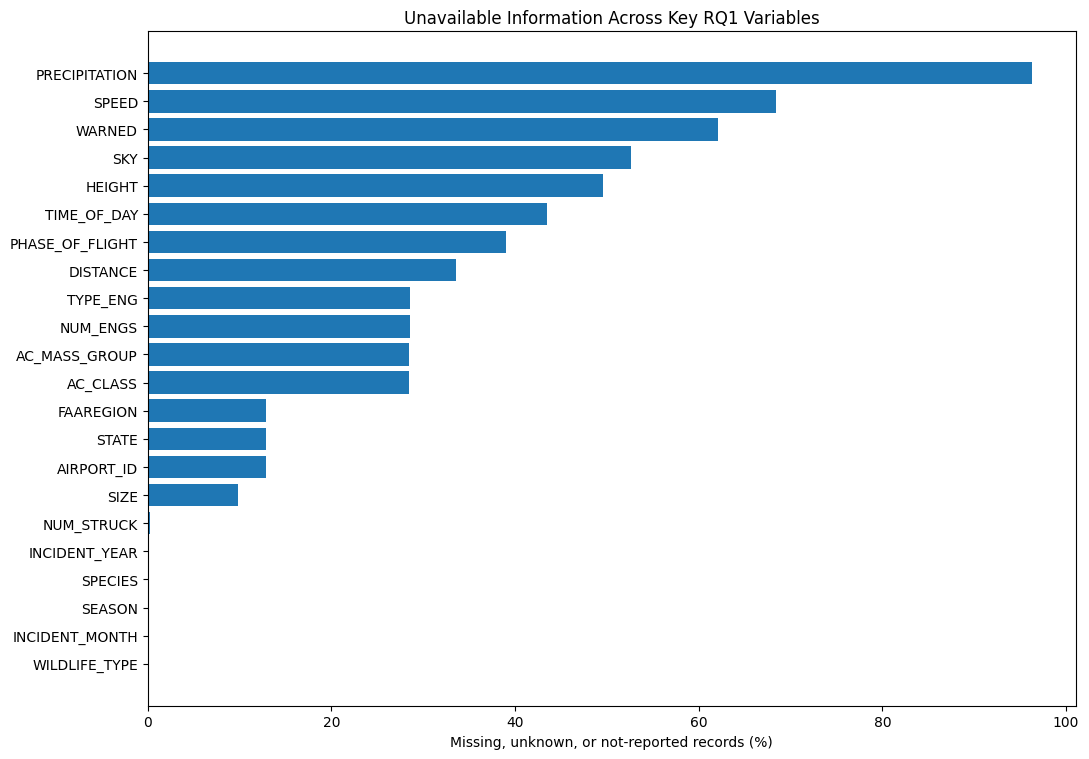

In [27]:

key_predictors = [
    "INCIDENT_YEAR",
    "INCIDENT_MONTH",
    "SEASON",
    "TIME_OF_DAY",
    "FAAREGION",
    "STATE",
    "AIRPORT_ID",
    "WILDLIFE_TYPE",
    "SPECIES",
    "SIZE",
    "NUM_STRUCK",
    "AC_CLASS",
    "AC_MASS_GROUP",
    "TYPE_ENG",
    "NUM_ENGS",
    "PHASE_OF_FLIGHT",
    "WARNED",
    "HEIGHT",
    "SPEED",
    "DISTANCE",
    "SKY",
    "PRECIPITATION",
]
key_predictors = [c for c in key_predictors if c in analysis_df.columns]

unavailable_labels = {
    "", "unknown", "unknown wildlife", "not reported",
    "unk", "zzzz", "nan", "none"
}

availability_rows = []
for field in key_predictors:
    series = analysis_df[field]
    missing_mask = series.isna()

    if (
        pd.api.types.is_object_dtype(series)
        or pd.api.types.is_string_dtype(series)
        or isinstance(series.dtype, pd.CategoricalDtype)
    ):
        normalized = series.astype("string").str.strip().str.lower()
        unavailable_mask = missing_mask | normalized.isin(unavailable_labels)
    else:
        unavailable_mask = missing_mask

    availability_rows.append({
        "Variable": field,
        "Available_Records": int((~unavailable_mask).sum()),
        "Unavailable_Records": int(unavailable_mask.sum()),
        "Unavailable_Percentage": unavailable_mask.mean() * 100,
    })

predictor_availability = (
    pd.DataFrame(availability_rows)
    .sort_values("Unavailable_Percentage", ascending=False)
    .reset_index(drop=True)
)
save_table(predictor_availability, "data_quality_predictor_availability.csv")
display(predictor_availability)

plot_availability = predictor_availability.sort_values(
    "Unavailable_Percentage", ascending=True
)
fig, ax = plt.subplots(figsize=(11, max(6, 0.35 * len(plot_availability))))
ax.barh(
    plot_availability["Variable"],
    plot_availability["Unavailable_Percentage"]
)
ax.set_title("Unavailable Information Across Key RQ1 Variables")
ax.set_xlabel("Missing, unknown, or not-reported records (%)")
ax.set_ylabel("")
plt.tight_layout()
save_figure(fig, "data_quality_predictor_availability.png")
plt.show()

# Export the Notebook 02 feature review beside the descriptive results.
if not feature_eligibility.empty:
    proposal_alignment = feature_eligibility.loc[
        feature_eligibility["field"].isin(key_predictors + ["INDICATED_DAMAGE"])
    ].copy()
    save_table(proposal_alignment, "data_quality_feature_eligibility_alignment.csv")


### Availability of key RQ1 variables

Data availability varied considerably across the variables used for RQ1. `PRECIPITATION` had the highest proportion of unavailable information at 96.2%, followed by `SPEED` (68.4%), `WARNED` (62.1%), `SKY` (52.6%), and `HEIGHT` (49.6%). These variables should therefore be interpreted cautiously and may have limited usefulness in the predictive models unless missingness is handled explicitly.

Aircraft characteristics such as engine type, number of engines, aircraft mass group, and aircraft class were unavailable in approximately 28% of records. Geographic variables were more complete, although airport, state, and FAA region information was unavailable in about 12.9% of records.

Wildlife size was available for approximately 90% of records, while number struck was nearly complete. Temporal variables, species, wildlife type, and season were complete in the analytical dataset. Because unavailable values may reflect missing, unknown, or unreported information rather than random data loss, they should not be removed automatically. Their treatment will be documented during feature preparation and modelling.

## 11. Sparse categories and historical support

High damage rates can be misleading when they are calculated from very few records. This section identifies low-volume categories and selected scenario combinations that may require a historical-support warning in later modelling and simulation notebooks.

The thresholds below are descriptive decision rules rather than statistical significance cut-offs:

- fewer than 100 records: **very limited support**;
- 100–499 records: **limited support**;
- 500 or more records: **broader support**.

The full counts remain available so that Notebook 04 can choose assumptions and tests appropriate to each variable.

In [28]:

def support_label(n):
    if pd.isna(n):
        return "Unavailable"
    if n < 100:
        return "Very limited"
    if n < 500:
        return "Limited"
    return "Broader"

support_specs = {
    "Wildlife size × aircraft mass": ["SIZE", "AC_MASS_GROUP"],
    "Wildlife size × phase of flight": ["SIZE", "PHASE_OF_FLIGHT"],
    "Wildlife type × season": ["WILDLIFE_TYPE", "SEASON"],
    "Number struck × aircraft mass": ["NUM_STRUCK", "AC_MASS_GROUP"],
}

support_tables = {}
for title, grouping in support_specs.items():
    if not set(grouping).issubset(analysis_df.columns):
        continue

    table = (
        analysis_df.groupby(grouping, dropna=False)
        .agg(
            records=("INDICATED_DAMAGE", "size"),
            damaged_records=("INDICATED_DAMAGE", "sum"),
            damage_rate=("INDICATED_DAMAGE", "mean"),
        )
        .reset_index()
    )
    table["damage_rate_pct"] = (table["damage_rate"] * 100).round(2)
    table["historical_support"] = table["records"].map(support_label)
    table = table.sort_values(["records", "damage_rate_pct"], ascending=[True, False])
    support_tables[title] = table

    safe_name = (
        title.lower()
        .replace(" × ", "_by_")
        .replace(" ", "_")
        .replace("-", "_")
    )
    save_table(table, f"support_{safe_name}.csv")

support_overview = pd.concat(
    [
        pd.DataFrame({
            "comparison": title,
            "total_combinations": len(table),
            "very_limited_combinations": (table["historical_support"] == "Very limited").sum(),
            "limited_combinations": (table["historical_support"] == "Limited").sum(),
            "broader_combinations": (table["historical_support"] == "Broader").sum(),
        }, index=[0])
        for title, table in support_tables.items()
    ],
    ignore_index=True,
)

save_table(support_overview, "historical_support_overview.csv")
display(support_overview)

for title, table in support_tables.items():
    print(f"\n{title}: combinations with the least historical support")
    display(table.head(10))


,comparison,total_combinations,very_limited_combinations,limited_combinations,broader_combinations
0,Wildlife size × aircraft mass,16,0,0,16
1,Wildlife size × phase of flight,48,8,11,29
2,Wildlife type × season,20,1,4,15
3,Number struck × aircraft mass,20,5,6,9



Wildlife size × aircraft mass: combinations with the least historical support


,SIZE,AC_MASS_GROUP,records,damaged_records,damage_rate,damage_rate_pct,historical_support
11,Not reported,Unknown,767,16,0.02086,2.09,Broader
2,Large,Medium,2643,1109,0.419599,41.96,Broader
9,Not reported,Light,3919,505,0.128859,12.89,Broader
10,Not reported,Medium,4227,229,0.054176,5.42,Broader
1,Large,Light,4461,2960,0.663528,66.35,Broader
3,Large,Unknown,5271,50,0.009486,0.95,Broader
5,Medium,Light,6874,2366,0.344196,34.42,Broader
0,Large,Heavy,7226,2341,0.323969,32.4,Broader
6,Medium,Medium,8467,1473,0.17397,17.4,Broader
13,Small,Light,12595,973,0.077253,7.73,Broader



Wildlife size × phase of flight: combinations with the least historical support


,SIZE,PHASE_OF_FLIGHT,records,damaged_records,damage_rate,damage_rate_pct,historical_support
33,Not reported,Parked,5,0,0.0,0.0,Very limited
9,Large,Parked,7,2,0.285714,28.57,Very limited
1,Large,Arrival,27,8,0.296296,29.63,Very limited
21,Medium,Parked,33,1,0.030303,3.03,Very limited
3,Large,Departure,68,18,0.264706,26.47,Very limited
45,Small,Parked,69,1,0.014493,1.45,Very limited
35,Not reported,Taxi,80,2,0.025,2.5,Very limited
13,Medium,Arrival,91,11,0.120879,12.09,Very limited
7,Large,Local,105,27,0.257143,25.71,Limited
11,Large,Taxi,118,19,0.161017,16.1,Limited



Wildlife type × season: combinations with the least historical support


,WILDLIFE_TYPE,SEASON,records,damaged_records,damage_rate,damage_rate_pct,historical_support
15,Reptile,Winter,30,0,0.0,0.0,Very limited
12,Reptile,Autumn,111,0,0.0,0.0,Limited
13,Reptile,Spring,202,2,0.009901,0.99,Limited
3,Bat,Winter,236,6,0.025424,2.54,Limited
14,Reptile,Summer,328,2,0.006098,0.61,Limited
19,Terrestrial mammal,Winter,991,216,0.217962,21.8,Broader
1,Bat,Spring,1018,10,0.009823,0.98,Broader
17,Terrestrial mammal,Spring,1176,229,0.194728,19.47,Broader
11,Other wildlife,Winter,1220,140,0.114754,11.48,Broader
16,Terrestrial mammal,Autumn,1811,520,0.287134,28.71,Broader



Number struck × aircraft mass: combinations with the least historical support


,NUM_STRUCK,AC_MASS_GROUP,records,damaged_records,damage_rate,damage_rate_pct,historical_support
15,More than 100,Unknown,4,0,0.0,0.0,Very limited
13,More than 100,Light,5,3,0.6,60.0,Very limited
14,More than 100,Medium,15,3,0.2,20.0,Very limited
12,More than 100,Heavy,33,14,0.424242,42.42,Very limited
19,Not reported,Unknown,63,3,0.047619,4.76,Very limited
7,11–100,Unknown,146,2,0.013699,1.37,Limited
5,11–100,Light,150,44,0.293333,29.33,Limited
18,Not reported,Medium,151,0,0.0,0.0,Limited
16,Not reported,Heavy,182,1,0.005495,0.55,Limited
17,Not reported,Light,285,122,0.42807,42.81,Limited


### Historical-support observation

The tables distinguish common combinations from scenarios supported by only a small number of historical reports. A high damage rate in a very limited category should be treated as unstable rather than automatically important.

These labels should be passed forward as warnings, not used to delete records. Notebook 04 should avoid broad inferential claims for sparse combinations, and the simulation stage should alert users when a requested scenario has limited or no close historical support.

## 12. Decisions and hand-off to Notebook 04

### Decisions retained from Notebook 02

- The notebook consumes the canonical analytical export and does not independently clean or redefine the modelling population.
- `INDICATED_DAMAGE` remains the primary outcome.
- Post-event variables such as `DAMAGE_LEVEL`, component damage, injuries, fatalities, costs, and operational consequences are used only to describe outcomes. They are not treated as predictors of the binary target.
- Unknown and not-reported values remain visible because they can reveal reporting patterns. They are not silently converted to substantive categories or zero.
- High-cardinality airport and exact-species results are reported with counts and minimum-volume filters for figures, while complete tables are preserved.

### Main descriptive conclusions

Reported strike volume rose strongly over the analytical period, while the proportion with reported damage generally declined. Seasonal counts and damage proportions followed different patterns: summer contained the most reports, whereas winter had the highest damage proportion. Large wildlife, larger reported numbers struck, light aircraft, and several non-ground flight phases showed elevated damage rates. These comparisons describe associations among reported records and do not establish causes.

The updated broad wildlife mapping also clarified the distinction between reporting frequency and damage proportion. Birds account for the overwhelming majority of standardized wildlife-type records, while terrestrial mammals are far less frequent but have the highest reported damage proportion among the broad groups. Because `WILDLIFE_TYPE` is an engineered grouping from Notebook 02, these frequencies should be interpreted according to the documented mapping rather than as unchanged raw FAA labels.

Denver International appeared prominently because it had the largest reporting volume among the leading airports, but its damage rate was comparatively low. This reinforces why report counts should not be interpreted as airport risk without flight-exposure data. Species results showed the same distinction: frequently reported species were not always the species with the highest damage rates. A separate ranking among identified species with at least 200 reports highlighted white-tailed deer, vultures, geese, and other large-bodied wildlife.

Several variables had substantial unavailable information, particularly precipitation, speed, warning status, sky condition, and height. Their availability also changed across years, so temporal comparisons should not assume constant reporting completeness. Sparse exact species, airports, and cross-factor combinations also require caution.

### Questions for Notebook 04

Notebook 04 should formally assess:

1. whether wildlife size and number struck remain associated with damage after controlling for aircraft and flight context;
2. whether aircraft mass, aircraft class, phase of flight, and warning status have practically meaningful associations;
3. whether the wildlife-size × aircraft-mass and wildlife-size × phase interactions are supported by sufficient observations;
4. whether temporal and geographic differences persist after accounting for other available variables and reporting-related missingness;
5. how conclusions change when unknown or not-reported categories are excluded;
6. which associations are robust enough to help interpret later model behaviour.

Notebook 04 should report sample sizes, effect sizes, confidence intervals, multiple-testing decisions, and an interpretable multivariable logistic-regression baseline rather than relying on p-values alone.


In [29]:

# Final descriptive output manifest
manifest_df = pd.DataFrame(output_manifest).drop_duplicates()

if not manifest_df.empty:
    manifest_path = OUTPUT_DIR / "03_output_manifest.csv"
    manifest_df.to_csv(manifest_path, index=False)

print(f"Descriptive tables and figures saved under: {OUTPUT_DIR.resolve()}")
print(f"Manifest entries: {len(manifest_df):,}")
display(manifest_df.tail(10))


Descriptive tables and figures saved under: C:\Users\davis\Programing\MDA_programs\Capstone\faa-wildlife-strike-damage-analysis\outputs\03_descriptive_analytics
Manifest entries: 94


,artifact_type,filename,relative_path,rows,columns
84,table,consequence_injuries_fatalities.csv,outputs\03_descriptive_analytics\tables\conseq...,2,3
85,figure,consequence_top10_component_damage.png,outputs\03_descriptive_analytics\figures\conse...,<NA>,<NA>
86,table,data_quality_predictor_availability.csv,outputs\03_descriptive_analytics\tables\data_q...,22,4
87,figure,data_quality_predictor_availability.png,outputs\03_descriptive_analytics\figures\data_...,<NA>,<NA>
88,table,data_quality_feature_eligibility_alignment.csv,outputs\03_descriptive_analytics\tables\data_q...,23,9
89,table,support_wildlife_size_by_aircraft_mass.csv,outputs\03_descriptive_analytics\tables\suppor...,16,7
90,table,support_wildlife_size_by_phase_of_flight.csv,outputs\03_descriptive_analytics\tables\suppor...,48,7
91,table,support_wildlife_type_by_season.csv,outputs\03_descriptive_analytics\tables\suppor...,20,7
92,table,support_number_struck_by_aircraft_mass.csv,outputs\03_descriptive_analytics\tables\suppor...,20,7
93,table,historical_support_overview.csv,outputs\03_descriptive_analytics\tables\histor...,4,5
